# Photometry Jupyter Notebook

## Imports

In [2]:
import os
os.environ['BOKEH_ALLOW_WS_ORIGIN'] = ("1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g")
print("BOKEH_ALLOW_WS_ORIGIN =", os.environ.get('BOKEH_ALLOW_WS_ORIGIN'))

from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord

import photutils
from photutils.psf import fit_2dgaussian
from photutils.centroids import centroid_2dg
from photutils.aperture import aperture_photometry, CircularAperture, CircularAnnulus
from astroquery.jplhorizons import Horizons

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar

from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import HoverTool
output_notebook()

from astroquery.simbad import Simbad

import warnings
warnings.filterwarnings('ignore')

BOKEH_ALLOW_WS_ORIGIN = 1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g


Loading BokehJS ...

## Configuration

In [3]:
# Plotting parameters

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = True
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['figure.dpi'] = 130

In [4]:
# Directory containing reduced FITS files
direc = 'C:/Users/Matylda/Documents/TGP'  # UPDATE THIS PATH

# Image codes for each standard star
codes1 = [167861, 167863, 167866, 167868, 167869, 167870, 167871, 167872, 167874, 167875, 167876, 167877]
codes2 = [167879, 167880, 167881, 167882, 167885, 167886, 167887, 167888, 167889, 167890, 167905, 167906]
codes3 = [167891, 167892, 167893, 167894, 167895, 167896, 167897, 167899, 167900, 167901, 167902, 167903, 167904]

# Image codes for asteroid observations
asteroid_codes = [167137, 167140, 167147, 167148, 167149, 167150, 167152, 167153, 167154, 167155, 167156, 167158, 167159, 167160, 167161, 167162, 167163, 167164, 167165, 167166, 167167, 167168]

# Filter mapping
filter_map = {
    'R': ['r', 'red', 'R'],
    'V': ['v', 'V'],
    'B': ['b', 'blue', 'B'],
    'I': ['i', 'I']
}

# Standard star RA/Dec coordinates (hours, degrees)
# Standard Star 1: RA = 20h 30m 03.4s, Dec = 39° 15' 21"
ss1_ra = (20 + 30/60 + 3.4/3600) * 15  # Convert to degrees
ss1_dec = 39 + 15/60 + 21/3600

# Standard Star 2: RA = 1h 52m 4.29s, Dec = 47° 1' 47.4"
ss2_ra = (1 + 52/60 + 4.29/3600) * 15
ss2_dec = 47 + 1/60 + 47.4/3600

# Standard Star 3: RA = 3h 44m 7s, Dec = 45° 6' 0.2"
ss3_ra = (3 + 44/60 + 7/3600) * 15
ss3_dec = 45 + 6/60 + 0.2/3600

# Asteroid information
asteroid_name = "Belgica"  # UPDATE THIS
observatory_code = "Z63"   # PIRATE observatory code

# Centroid refinement radius (pixels)
centroid_radius_ss1 = 35
centroid_radius_ss2 = 25
centroid_radius_ss3 = 35
centroid_radius_asteroid = 10

## Utility Functions

In [5]:
def snr(data, ap, an):
    """
    Calculate signal-to-noise ratio for aperture photometry.
    
    Parameters:
    -----------
    data : array
        Image data
    ap : CircularAperture
        Aperture for photometry
    an : CircularAnnulus
        Annulus for sky background estimation
    
    Returns:
    --------
    float : Signal-to-noise ratio
    """
    phot = aperture_photometry(data, ap)
    flux_ap = phot['aperture_sum'][0]

    annulus_masks = an.to_mask(method='center')
    annulus_data = annulus_masks.multiply(data)
    sky_pixels = annulus_data[annulus_masks.data > 0]
    sky_mean = np.mean(sky_pixels)
    sky_std = np.std(sky_pixels)

    n_pix = ap.area
    flux = flux_ap - sky_mean * n_pix

    gain = 1.39
    flux_e = flux * gain
    sigma_sky_e = sky_std * gain
    noise = np.sqrt(flux_e + n_pix * sigma_sky_e**2)

    return flux_e / noise

def normalize_filter_name(filter_str, filter_map):
    """
    Normalize filter name to standard single-letter format.
    
    Parameters:
    -----------
    filter_str : str
        Filter name from FITS header
    filter_map : dict
        Mapping of filter variations to standard names
    
    Returns:
    --------
    str : Normalized filter name
    """
    for standard, variants in filter_map.items():
        if filter_str in variants:
            return standard
    return filter_str

def get_airmass(header):
    """
    Extract airmass from FITS header, calculating if necessary.
    
    Parameters:
    -----------
    header : astropy.io.fits.Header
        FITS header
    
    Returns:
    --------
    float : Airmass value
    """
    if 'AIRMASS' in header:
        return header['AIRMASS']
    elif 'ALTITUDE' in header:
        alt = header['ALTITUDE']
        if float(alt) > 0:
            zenith = 90 - alt
            return 1.0 / np.cos(np.radians(zenith))
    return 1.0  # Default if can't determine

def flux_to_mag(norm_flux):
    """
    Convert normalized flux to instrumental magnitude.
    
    Parameters:
    -----------
    norm_flux : float
        Flux normalized by exposure time
    
    Returns:
    --------
    float : Instrumental magnitude
    """
    return -2.5 * np.log10(norm_flux)

def error_in_mag(standardFlux, skyFlux):
    """
    Calculate magnitude error from photon statistics.
    
    Parameters:
    -----------
    standardFlux : float
        Source flux
    skyFlux : float
        Sky background flux
    
    Returns:
    --------
    float : Magnitude error
    """
    C = standardFlux
    dC = np.sqrt(standardFlux + skyFlux)
    return (-2.5 / np.log(10)) * (dC / C)

## Location Finding Functions

These functions find and refine the pixel coordinates of stars and asteroids using:
1. WCS transformation from RA/Dec (or JPL Horizons for asteroids)
2. 2D Gaussian centroid refinement

In [6]:
def find_star_locations(codes, ra, dec, data_dir, ref_code=None, centroid_radius=25, visualize=True):
    """
    Find and refine star locations using WCS and centroid refinement.
    
    Parameters:
    -----------
    codes : list
        List of image codes
    ra : float
        Right ascension in degrees
    dec : float
        Declination in degrees
    data_dir : str
        Directory containing FITS files
    ref_code : int, optional
        Reference image code for missing WCS headers
    centroid_radius : int
        Radius for centroid cutout in pixels
    visualize : bool
        Whether to display visualization
    
    Returns:
    --------
    tuple : (data, locations, headers)
        - data: list of image arrays
        - locations: list of (x, y) refined pixel coordinates
        - headers: list of FITS headers
    """
    
    # Load reference WCS if provided
    ref_wcs = None
    if ref_code is not None:
        with fits.open(f'{data_dir}/{ref_code}.fits') as ref:
            ref_hdr = ref[0].header.copy()
            ref_wcs = WCS(ref_hdr)
    
    # First pass: get approximate locations
    data = []
    locs_approx = []
    hdrs = []
    
    for c in codes:
        with fits.open(f'{data_dir}/{c}.fits') as file:
            hdr = file[0].header.copy()
            
            # If CRPIX is missing, copy WCS from reference
            if 'CRPIX1' not in hdr or 'CRPIX2' not in hdr:
                hdr.update(ref_wcs.to_header())
            
            # Correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)
            
            # Convert RA/Dec to pixel coordinates
            px, py = wcs.world_to_pixel_values(ra, dec)
            
            image = file[0].data
            data.append(image)
            locs_approx.append((px, py))
            hdrs.append(hdr)
    
    # Second pass: refine locations using 2D Gaussian centroid
    r = centroid_radius
    locs_refined = []
    
    if visualize:
        n_images = len(data)
        ncols = min(4, n_images)
        nrows = (n_images + ncols - 1) // ncols
        fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
        if n_images == 1:
            axs = [axs]
        else:
            axs = axs.flatten() if nrows > 1 else axs
    
    for i, (d, l) in enumerate(zip(data, locs_approx)):
        x0, y0 = int(np.round(l[0])), int(np.round(l[1]))
        
        # Extract cutout around approximate location
        cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]
        
        # Find centroid in cutout
        x_c, y_c = centroid_2dg(cutout)
        
        # Convert back to full image coordinates
        x_refined = x0 - r + x_c
        y_refined = y0 - r + y_c
        
        locs_refined.append((x_refined, y_refined))
        
        if visualize:
            vn, vx = np.percentile(d, [5, 99])
            axs[i].imshow(d, cmap="gray", vmin=vn, vmax=vx)
            axs[i].add_patch(Circle((x_refined, y_refined), radius=10, 
                                   edgecolor="red", facecolor="none", linewidth=2))
            axs[i].add_patch(Circle((x0, y0), radius=10, 
                                   edgecolor="blue", facecolor="none", linewidth=2))
            axs[i].set_xlim(x_refined-25, x_refined+25)
            axs[i].set_ylim(y_refined-25, y_refined+25)
            axs[i].set_title(f'Image {codes[i]}')
    
    if visualize:
        # Hide unused subplots
        for i in range(len(data), len(axs)):
            axs[i].axis('off')
        fig.tight_layout()
        plt.show()
    
    return data, locs_refined, hdrs

def find_asteroid_locations(codes, asteroid_name, observatory_code, data_dirs, 
                           centroid_radius=10, visualize=True):
    """
    Find and refine asteroid locations using JPL Horizons ephemeris.
    
    Parameters:
    -----------
    codes : list
        List of image codes
    asteroid_name : str
        Name of the asteroid
    observatory_code : str
        IAU observatory code
    data_dirs : dict
        Dictionary mapping special codes to alternate directories
    centroid_radius : int
        Radius for centroid cutout in pixels
    visualize : bool
        Whether to display visualization
    
    Returns:
    --------
    tuple : (data, locations, headers)
        - data: list of image arrays
        - locations: list of (x, y) refined pixel coordinates
        - headers: list of FITS headers
    """
    # First pass: get approximate locations using Horizons
    data = []
    locs_approx = []
    hdrs = []
    
    for c in codes:
        # Determine which directory to use
        data_dir = data_dirs.get(c, data_dirs['default'])
        
        with fits.open(f'{data_dir}/{c}.fits') as file:
            hdr = file[0].header.copy()
            
            # Query JPL Horizons for ephemeris
            obs_time = Time(hdr["DATE-OBS"], format="isot", scale="utc")
            obj = Horizons(id=asteroid_name, location=observatory_code, epochs=obs_time.jd)
            eph = obj.ephemerides()
            ra = eph["RA"][0]
            dec = eph["DEC"][0]
            
            # Correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)
            
            # Convert RA/Dec to pixel coordinates
            px, py = wcs.world_to_pixel_values(ra, dec)
            
            image = file[0].data
            data.append(image)
            locs_approx.append((px, py))
            hdrs.append(hdr)
    
    # Second pass: refine locations using 2D Gaussian centroid
    r = centroid_radius
    locs_refined = []
    
    if visualize:
        n_images = len(data)
        ncols = min(5, n_images)
        nrows = (n_images + ncols - 1) // ncols
        fig, axs = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
        if n_images == 1:
            axs = [axs]
        else:
            axs = axs.flatten() if nrows > 1 else axs
    
    for i, (d, l) in enumerate(zip(data, locs_approx)):
        x0, y0 = int(np.round(l[0])), int(np.round(l[1]))
        
        # Extract cutout around approximate location
        cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]
        
        # Find centroid in cutout
        x_c, y_c = centroid_2dg(cutout)
        
        # Convert back to full image coordinates
        x_refined = x0 - r + x_c
        y_refined = y0 - r + y_c
        
        locs_refined.append((x_refined, y_refined))
        
        if visualize:
            vn, vx = np.percentile(d, [5, 99])
            axs[i].imshow(d, cmap="gray", vmin=vn, vmax=vx)
            axs[i].add_patch(Circle((x_refined, y_refined), radius=6, 
                                   edgecolor="red", facecolor="none", linewidth=2))
            axs[i].add_patch(Circle((x0, y0), radius=6, 
                                   edgecolor="blue", facecolor="none", linewidth=2))
            axs[i].set_xlim(x_refined-10, x_refined+10)
            axs[i].set_ylim(y_refined-10, y_refined+10)
            axs[i].set_title(f'{codes[i]}')
            axs[i].axis('off')
    
    if visualize:
        # Hide unused subplots
        for i in range(len(data), len(axs)):
            axs[i].axis('off')
        fig.tight_layout()
        plt.show()
    
    return data, locs_refined, hdrs

## Find Star and Asteroid Locations

Run this section to automatically find and refine all source locations.

Finding Standard Star 1 locations...


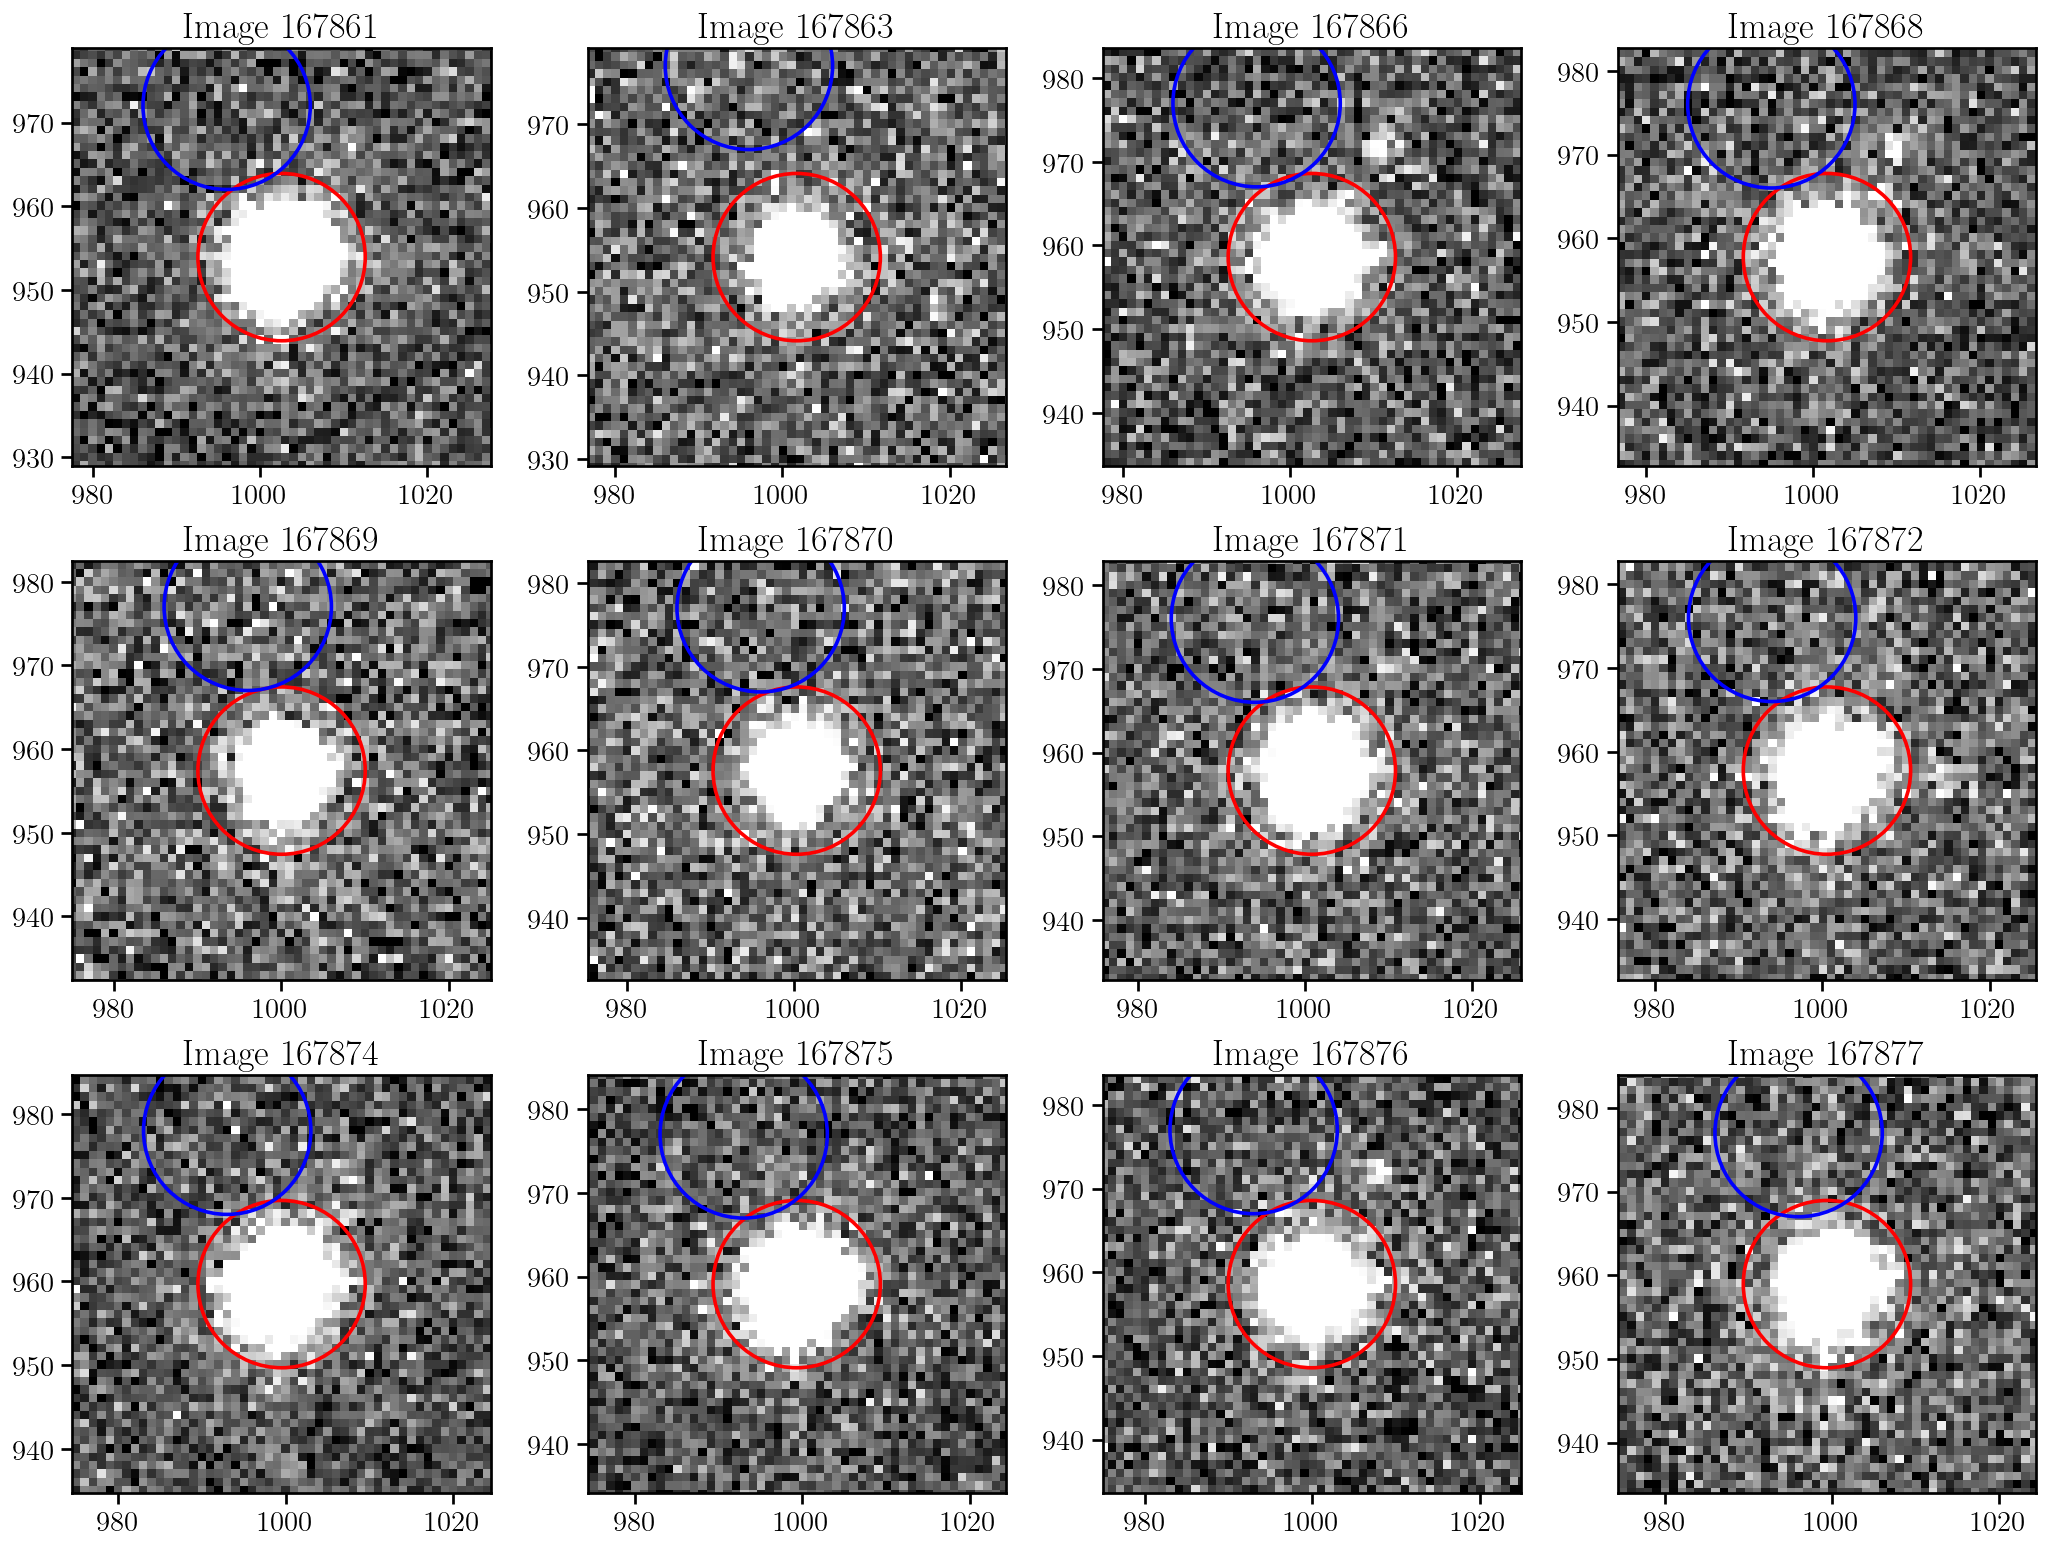

Found 12 locations for Standard Star 1


In [7]:
print("Finding Standard Star 1 locations...")
data1, locs1, hdrs1 = find_star_locations(
    codes1, ss1_ra, ss1_dec, 
    f'{direc}/Reduced_data_day3',
    ref_code=167866,
    centroid_radius=centroid_radius_ss1,
    visualize=True
)
print(f"Found {len(locs1)} locations for Standard Star 1")

Finding Standard Star 2 locations...


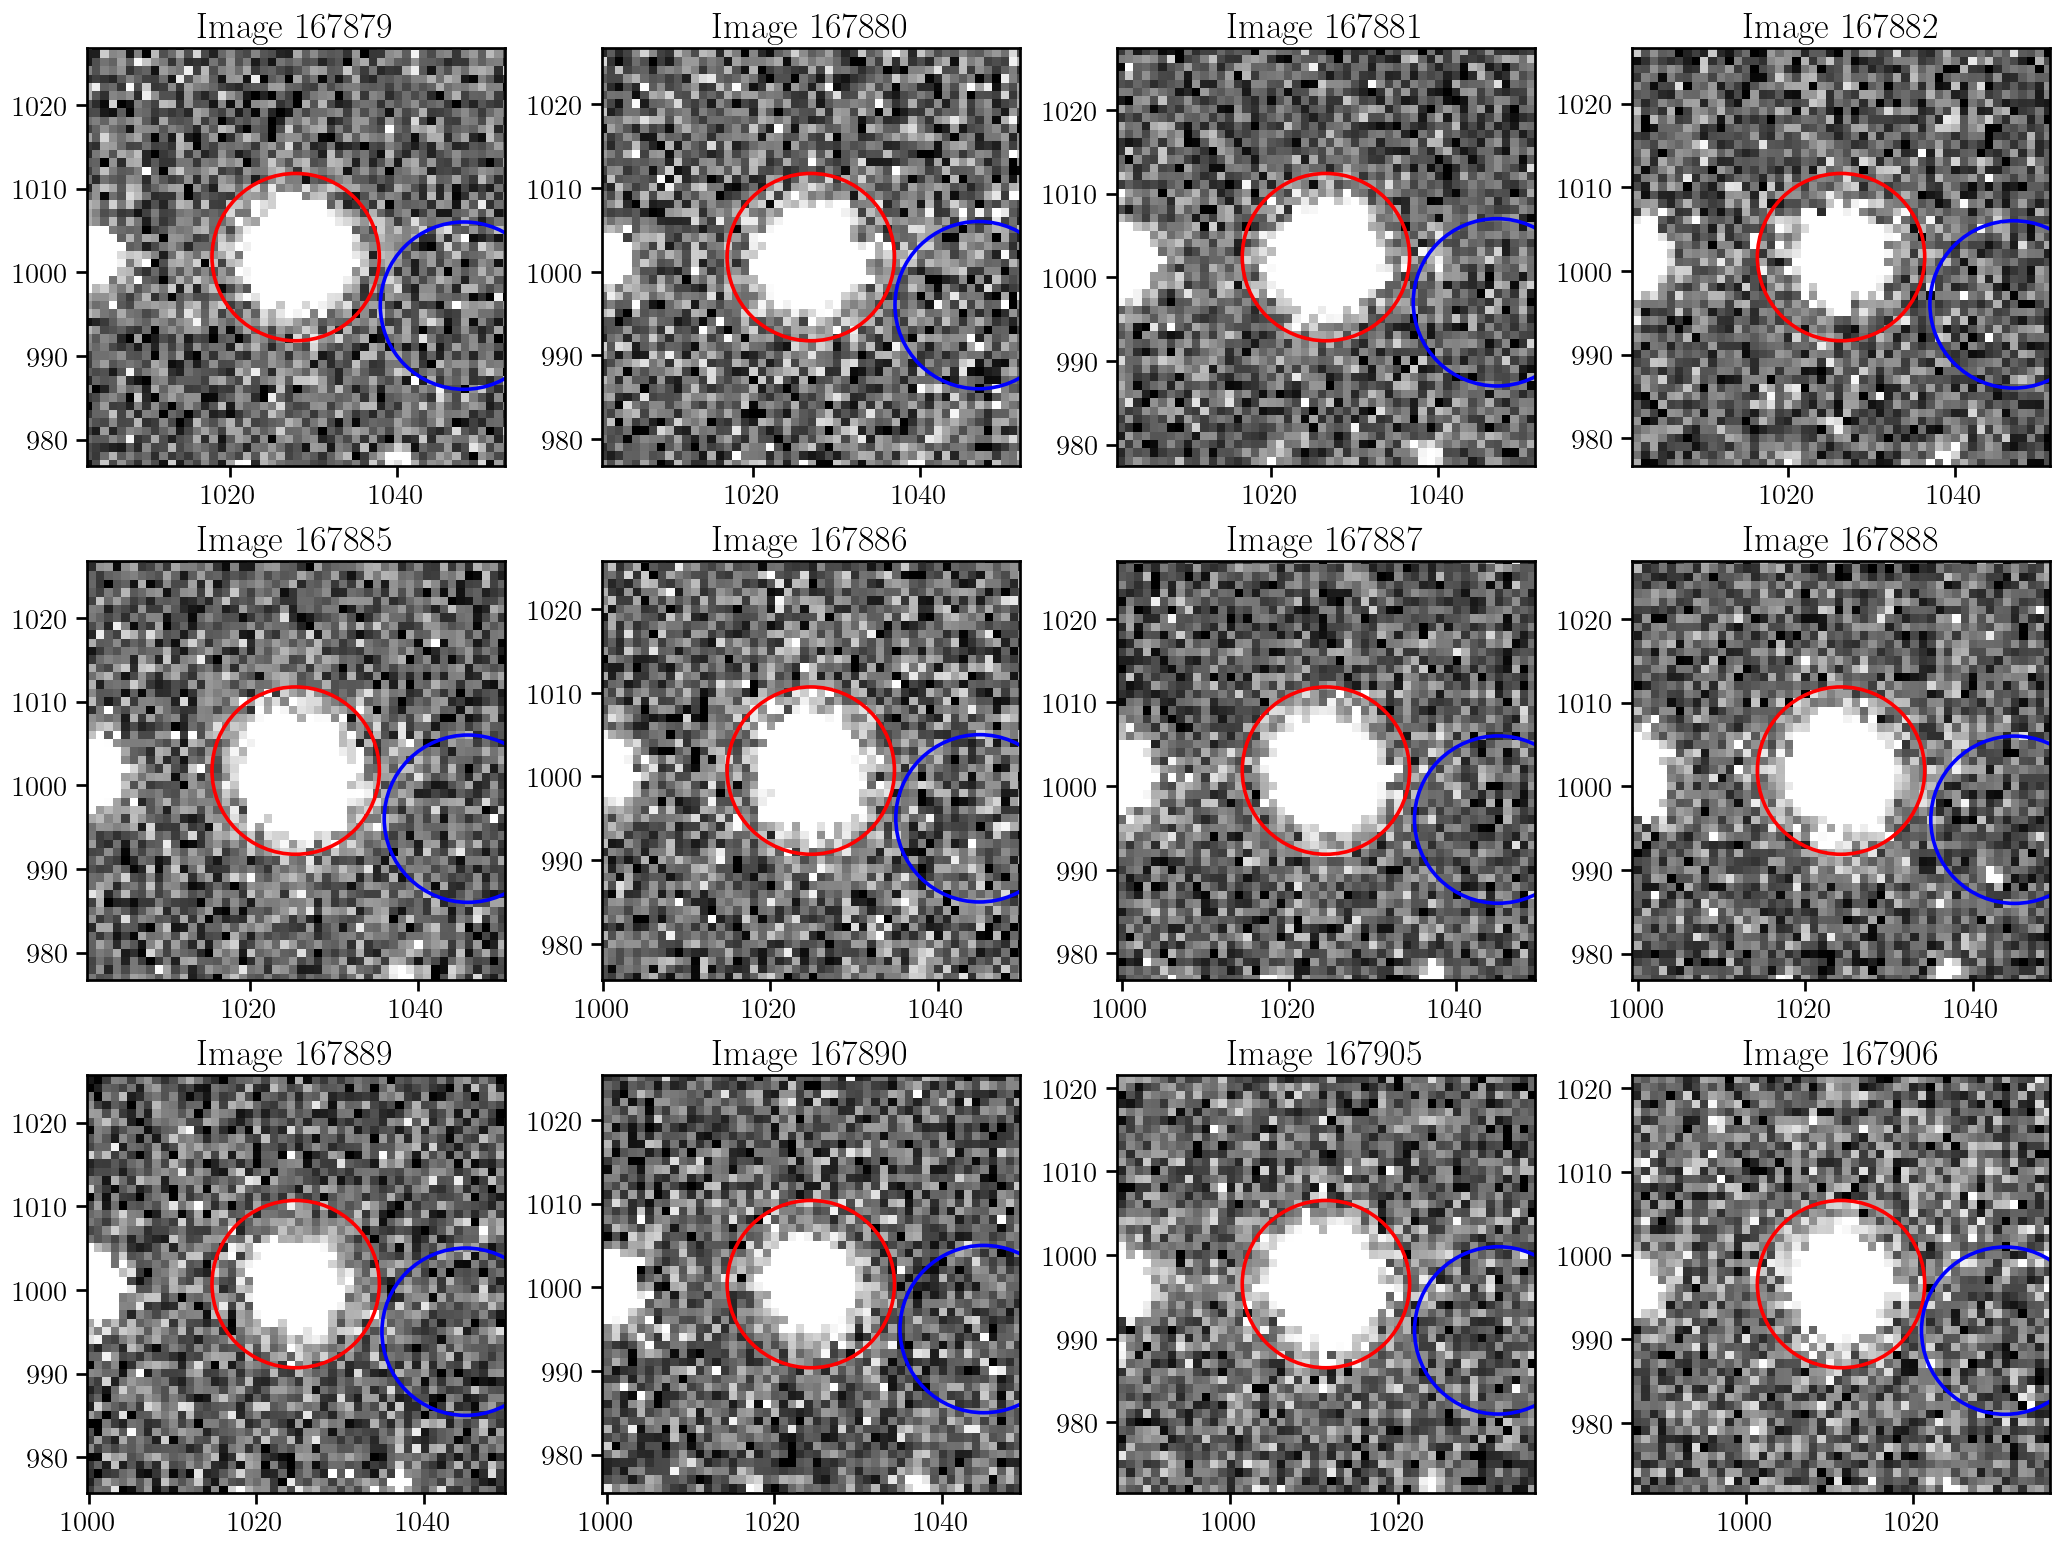

Found 12 locations for Standard Star 2


In [8]:
print("Finding Standard Star 2 locations...")
data2, locs2, hdrs2 = find_star_locations(
    codes2, ss2_ra, ss2_dec,
    f'{direc}/Reduced_data_day3',
    ref_code=167879,  # Reference image for missing WCS
    centroid_radius=centroid_radius_ss2,
    visualize=True
)
print(f"Found {len(locs2)} locations for Standard Star 2")

Finding Standard Star 3 locations...


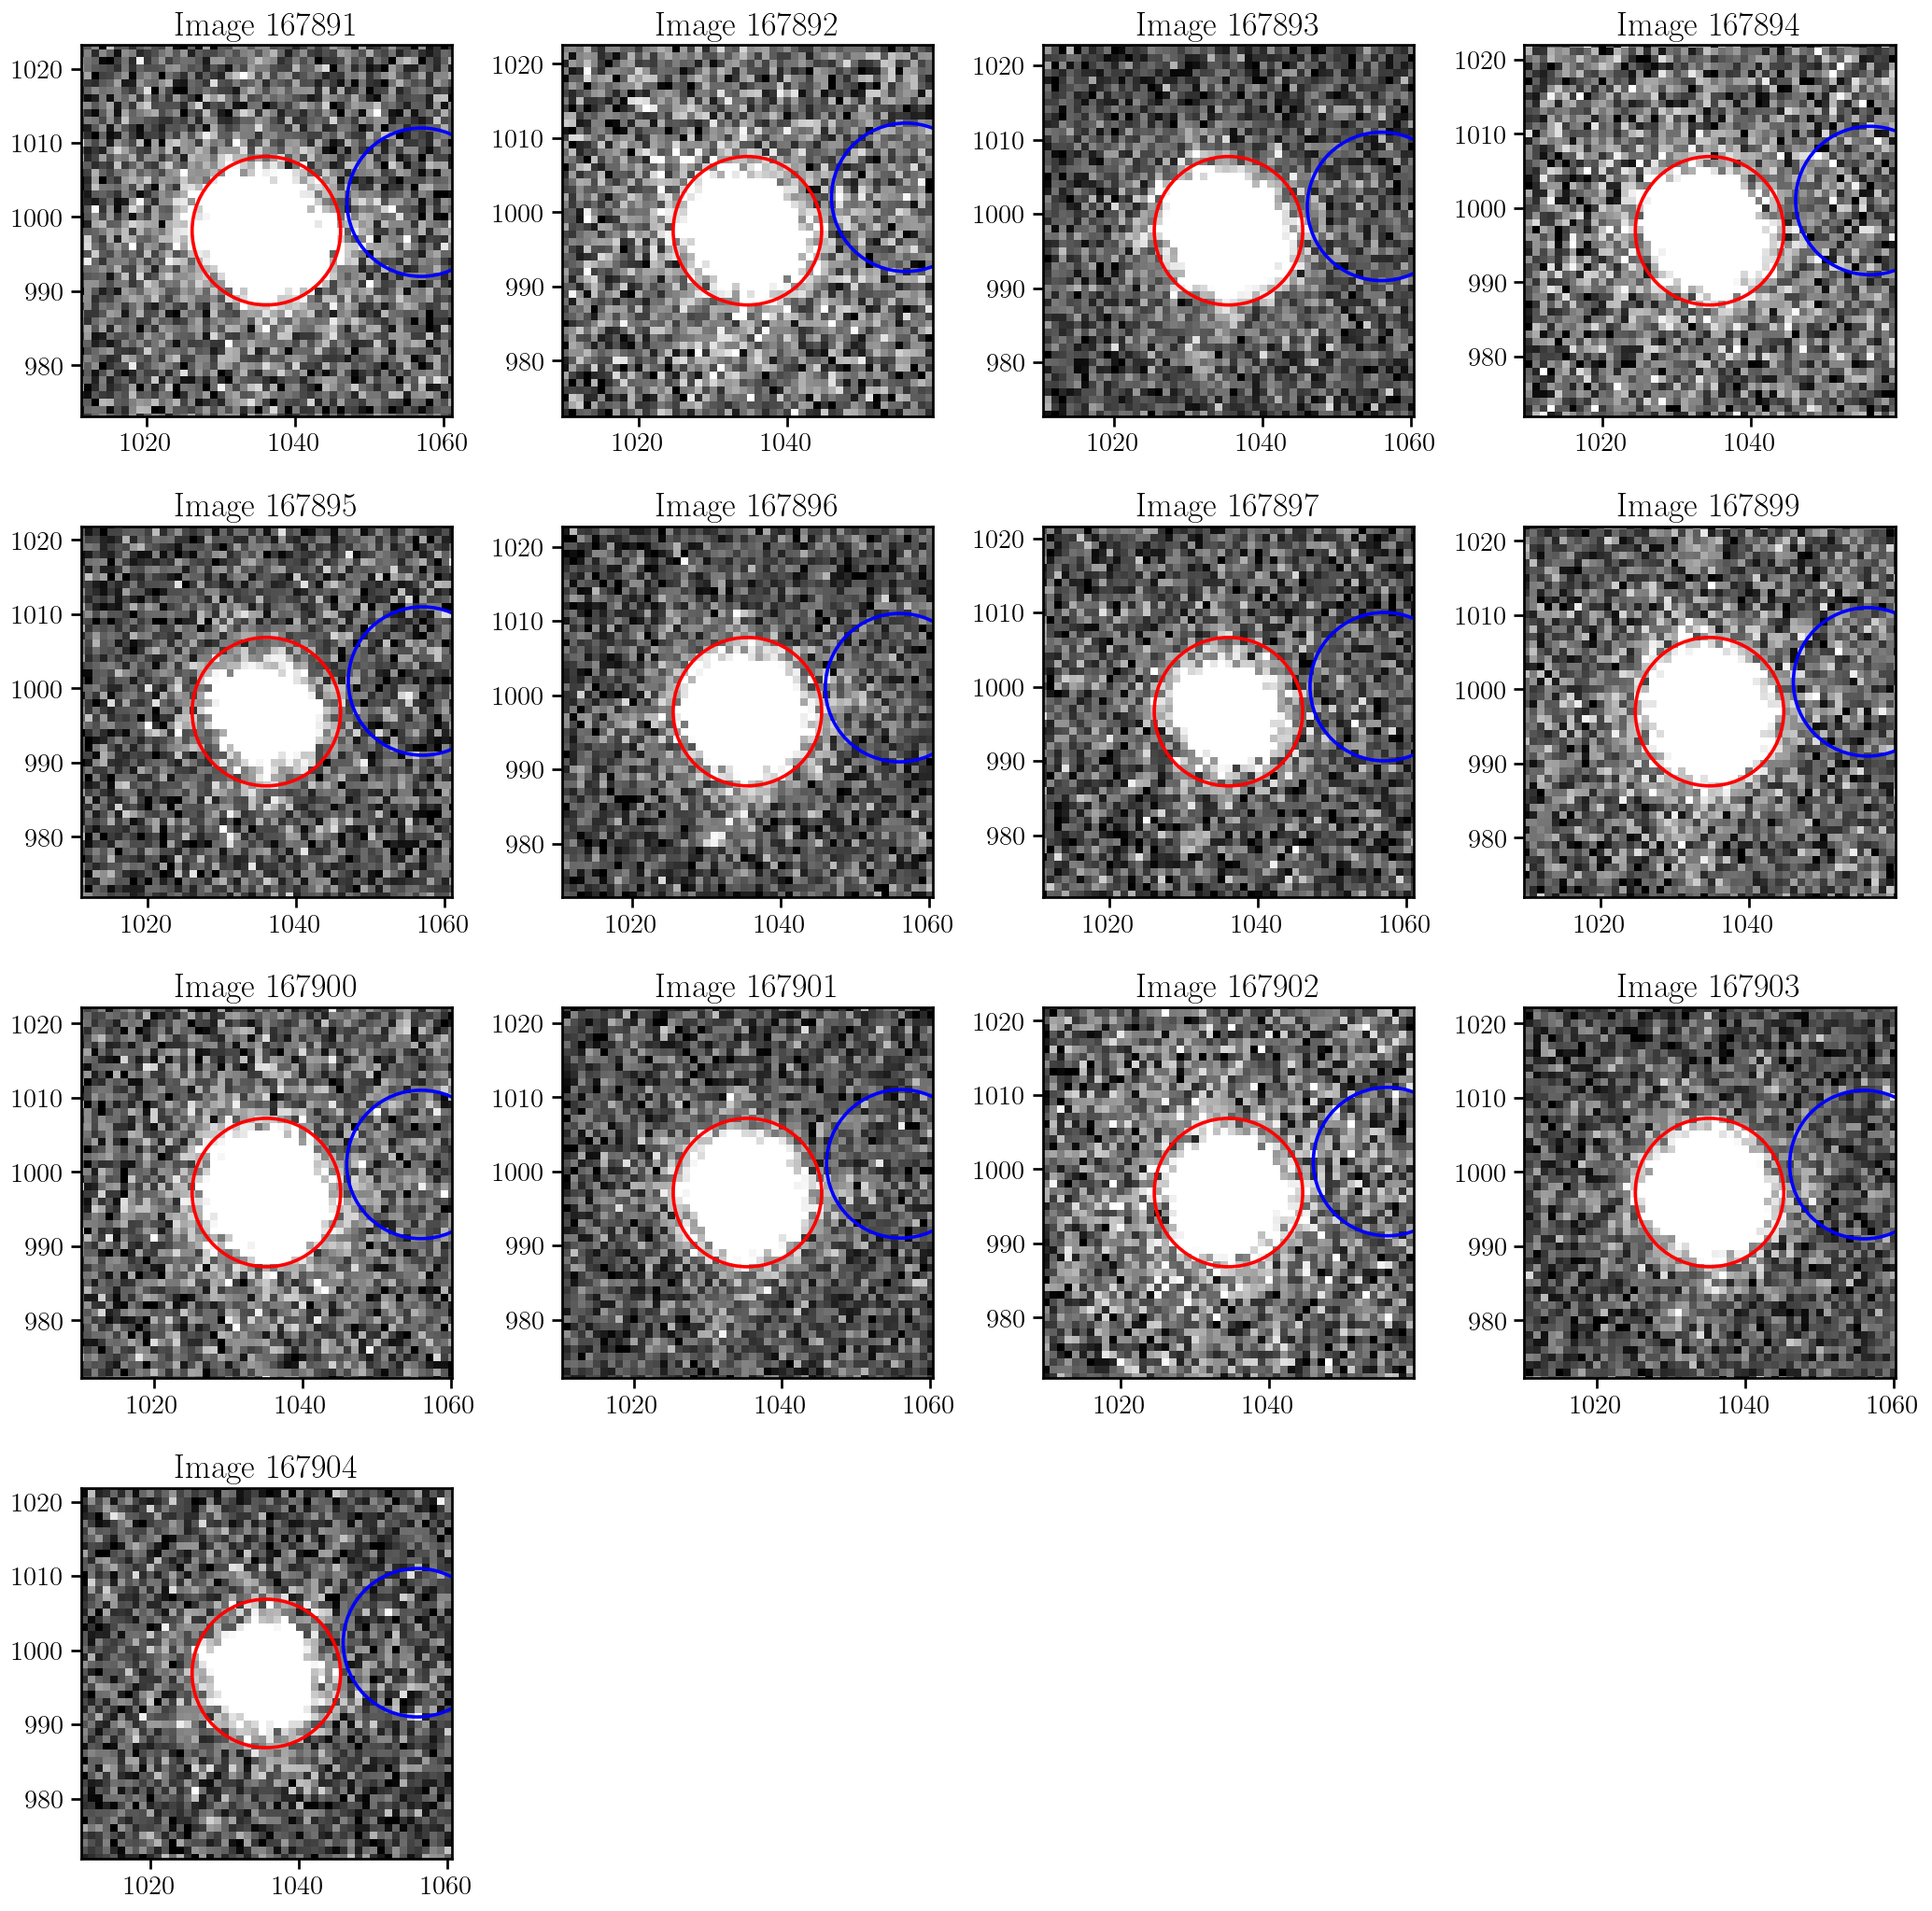

Found 13 locations for Standard Star 3


In [9]:
print("Finding Standard Star 3 locations...")
data3, locs3, hdrs3 = find_star_locations(
    codes3, ss3_ra, ss3_dec,
    f'{direc}/Reduced_data_day3',
    ref_code=167891,  # Reference image for missing WCS
    centroid_radius=centroid_radius_ss3,
    visualize=True
)
print(f"Found {len(locs3)} locations for Standard Star 3")

Finding Belgica locations using JPL Horizons...


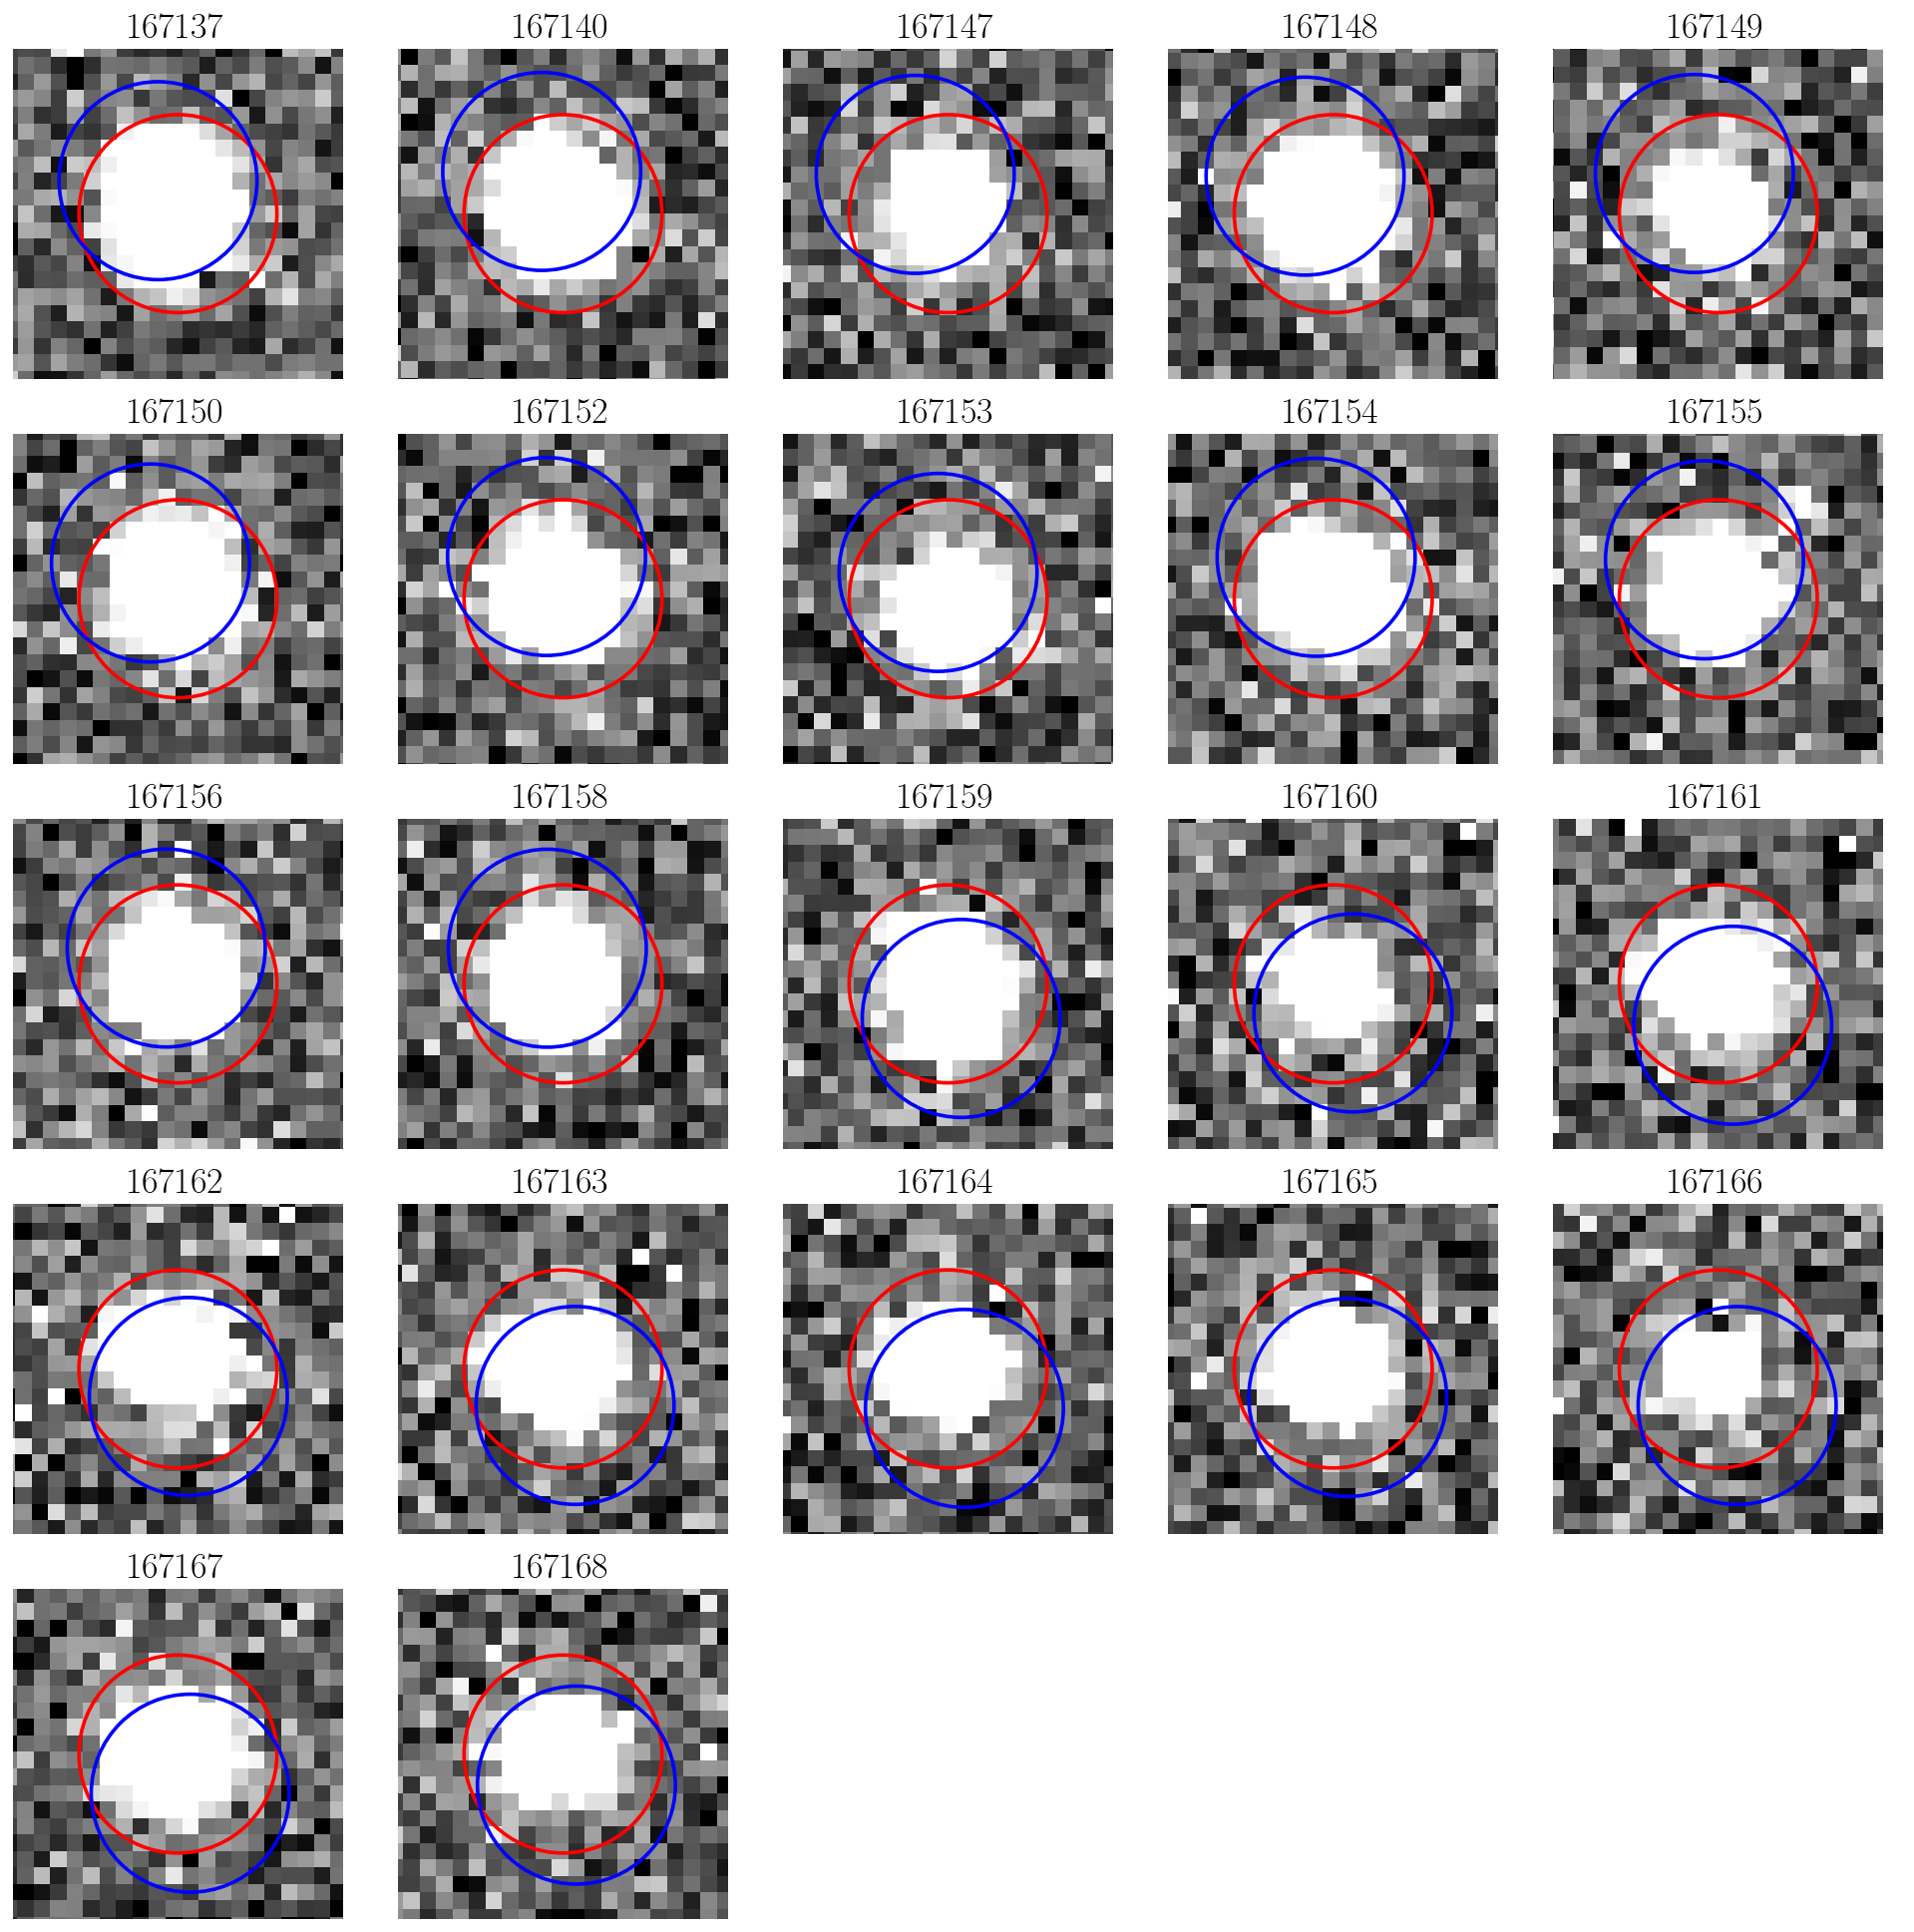

Found 22 locations for Belgica


In [10]:
print(f"Finding {asteroid_name} locations using JPL Horizons...")

# Define which images are in alternate directories
asteroid_data_dirs = {
    'default': f'{direc}/Reduced_data_day2',
    167153: f'{direc}/Reduced_data_I',
    167162: f'{direc}/Reduced_data_I',
    167168: f'{direc}/Reduced_data_I'
}

data_asteroid, locs_asteroid, hdrs_asteroid = find_asteroid_locations(
    asteroid_codes, asteroid_name, observatory_code,
    asteroid_data_dirs,
    centroid_radius=centroid_radius_asteroid,
    visualize=True
)
print(f"Found {len(locs_asteroid)} locations for {asteroid_name}")

## Aperture Optimization

Optimizing apertures for Standard Star 1...


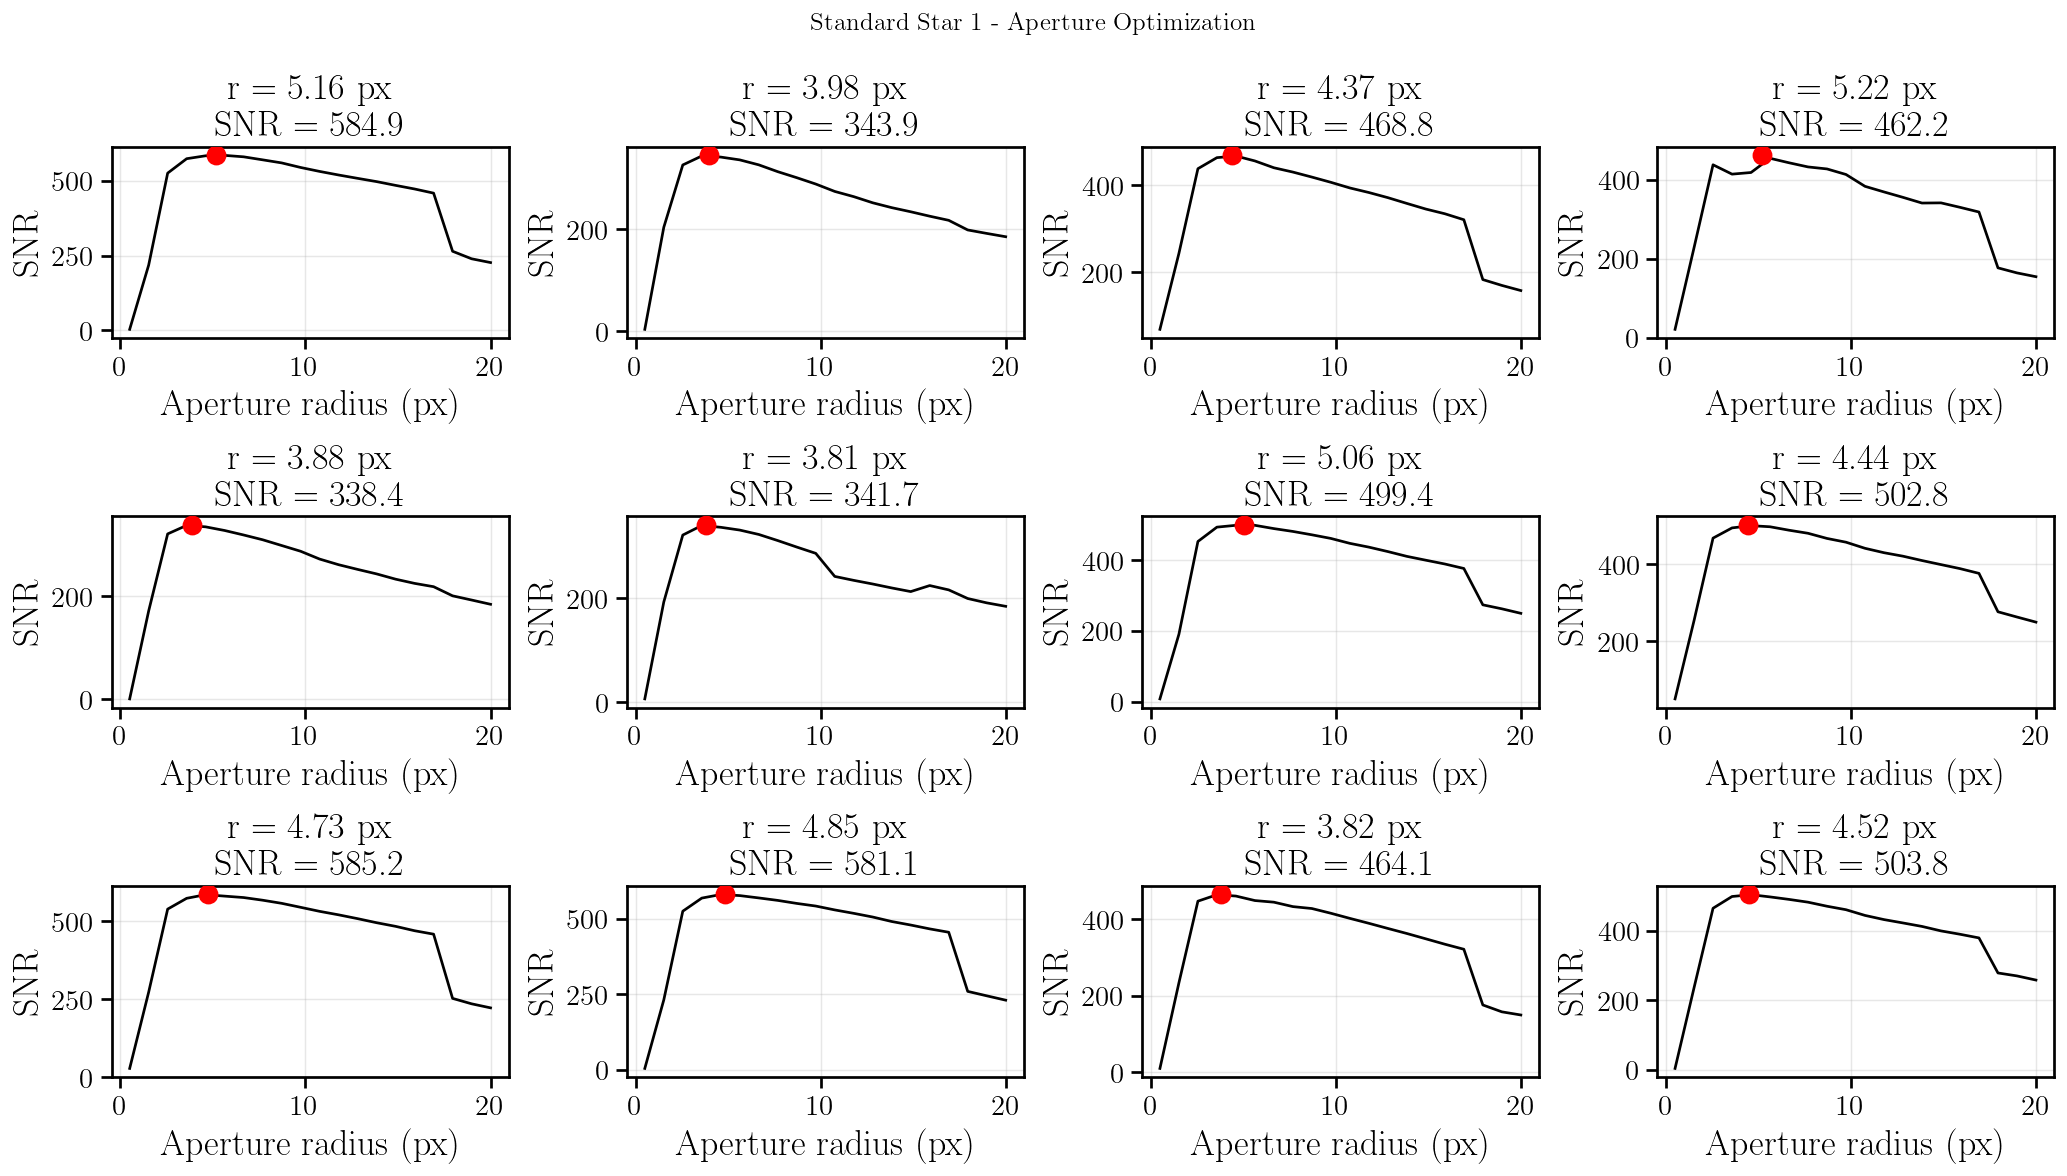


Optimizing apertures for Standard Star 2...


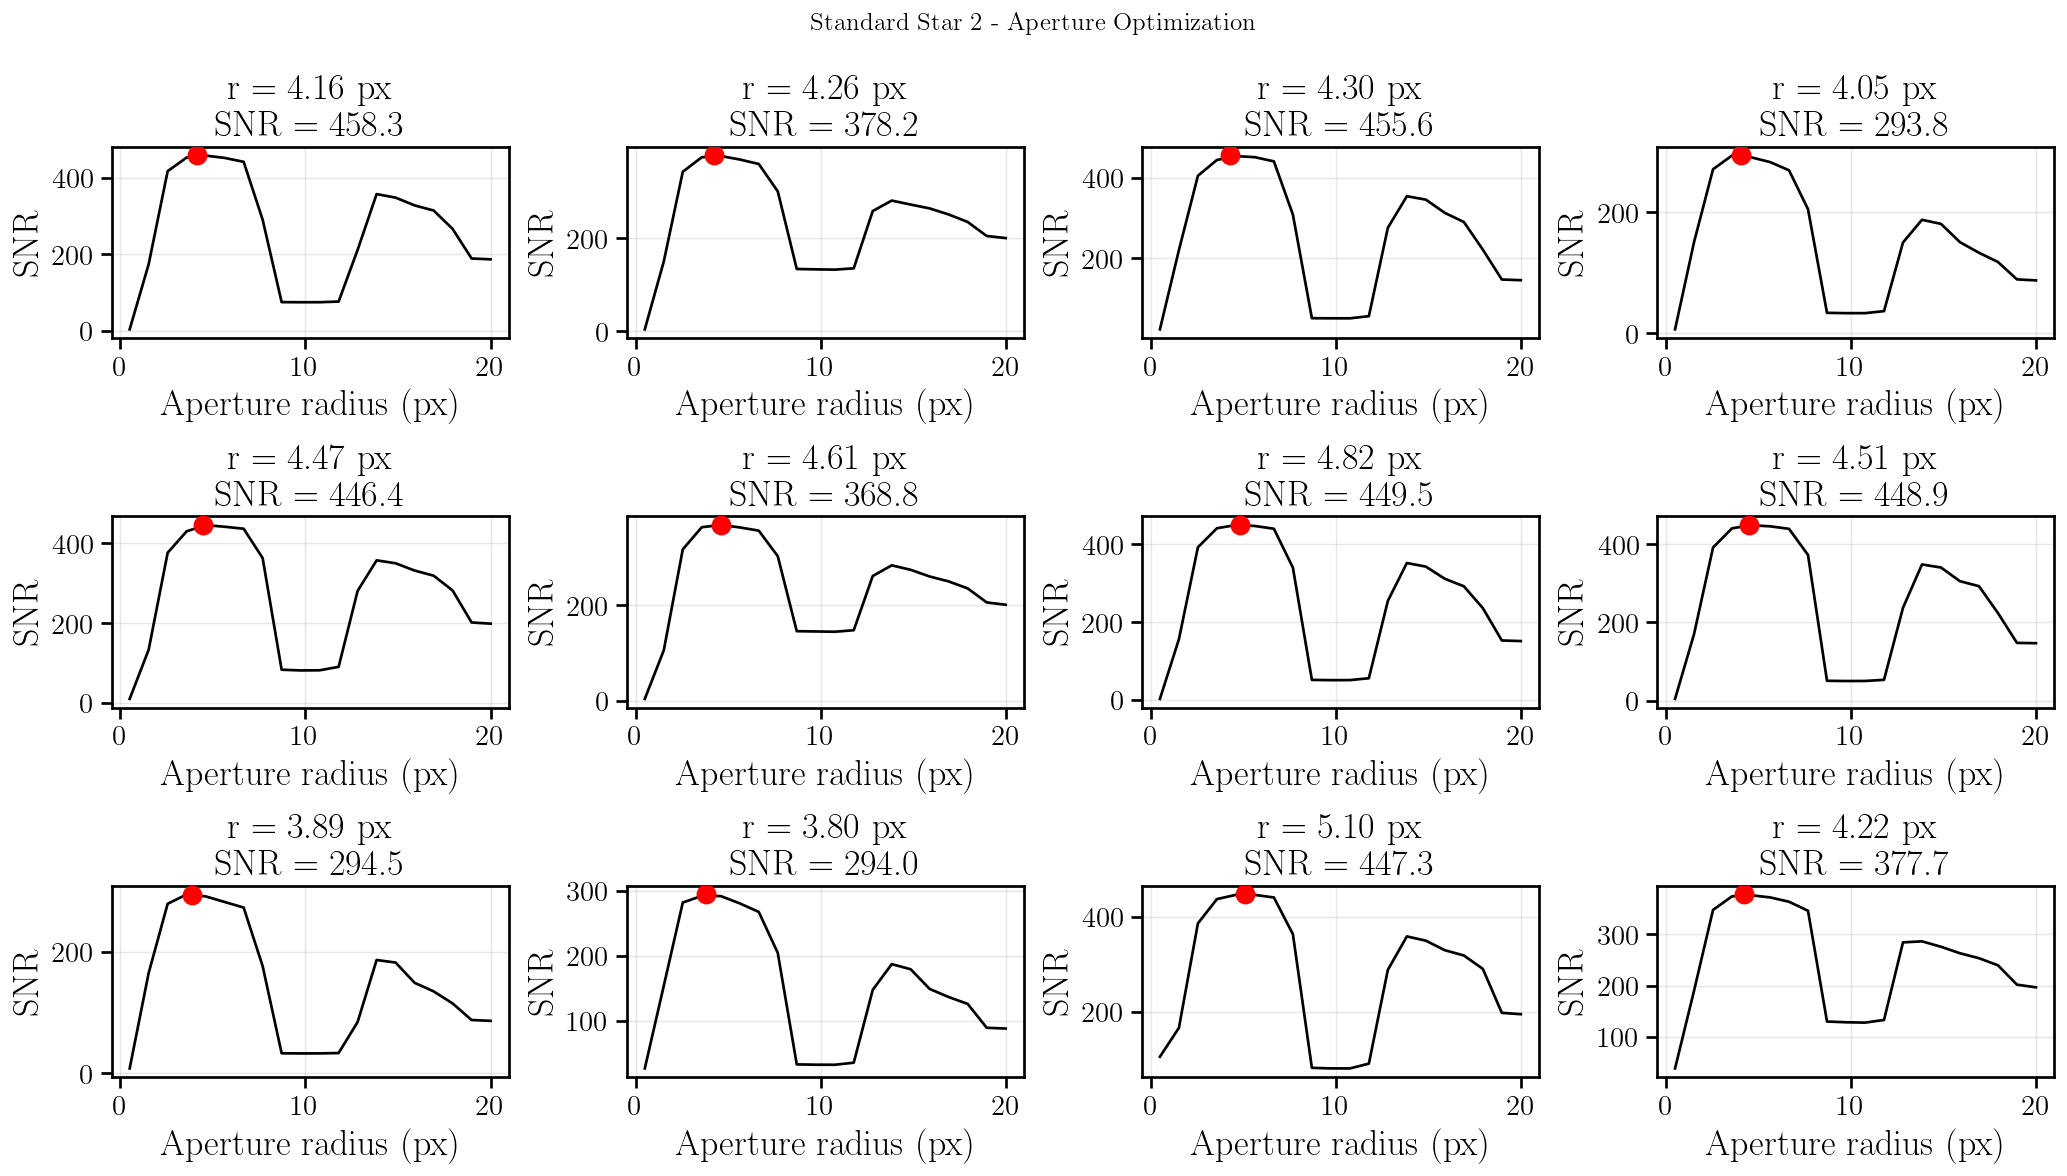


Optimizing apertures for Standard Star 3...


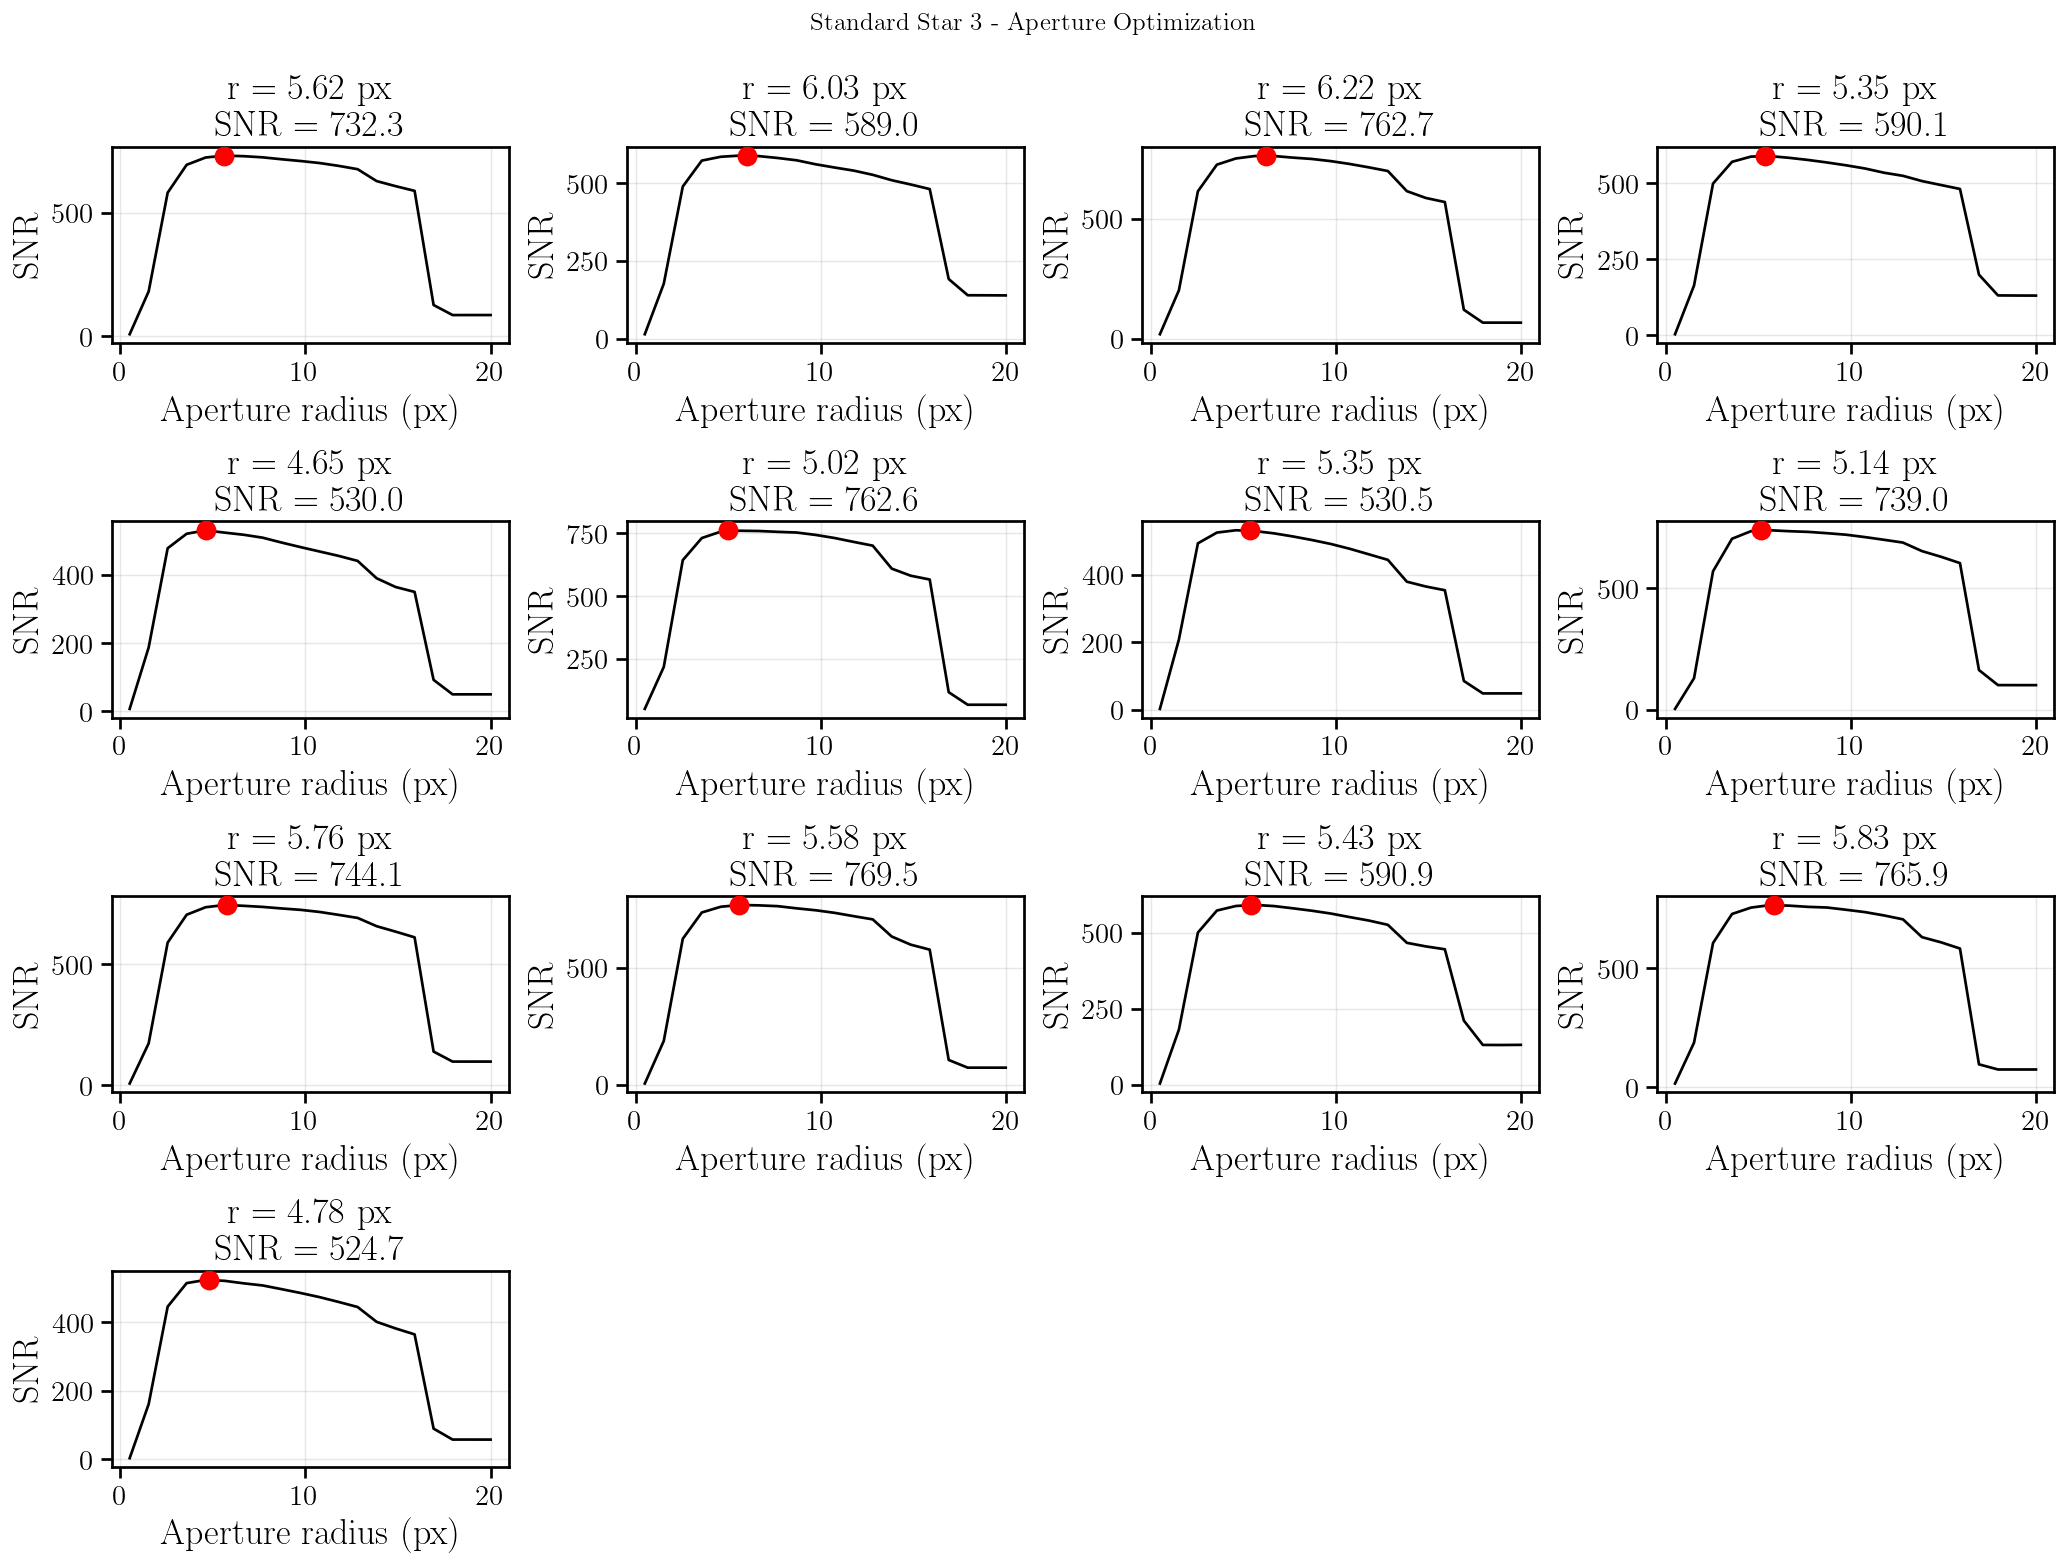


Optimizing apertures for Belgica...


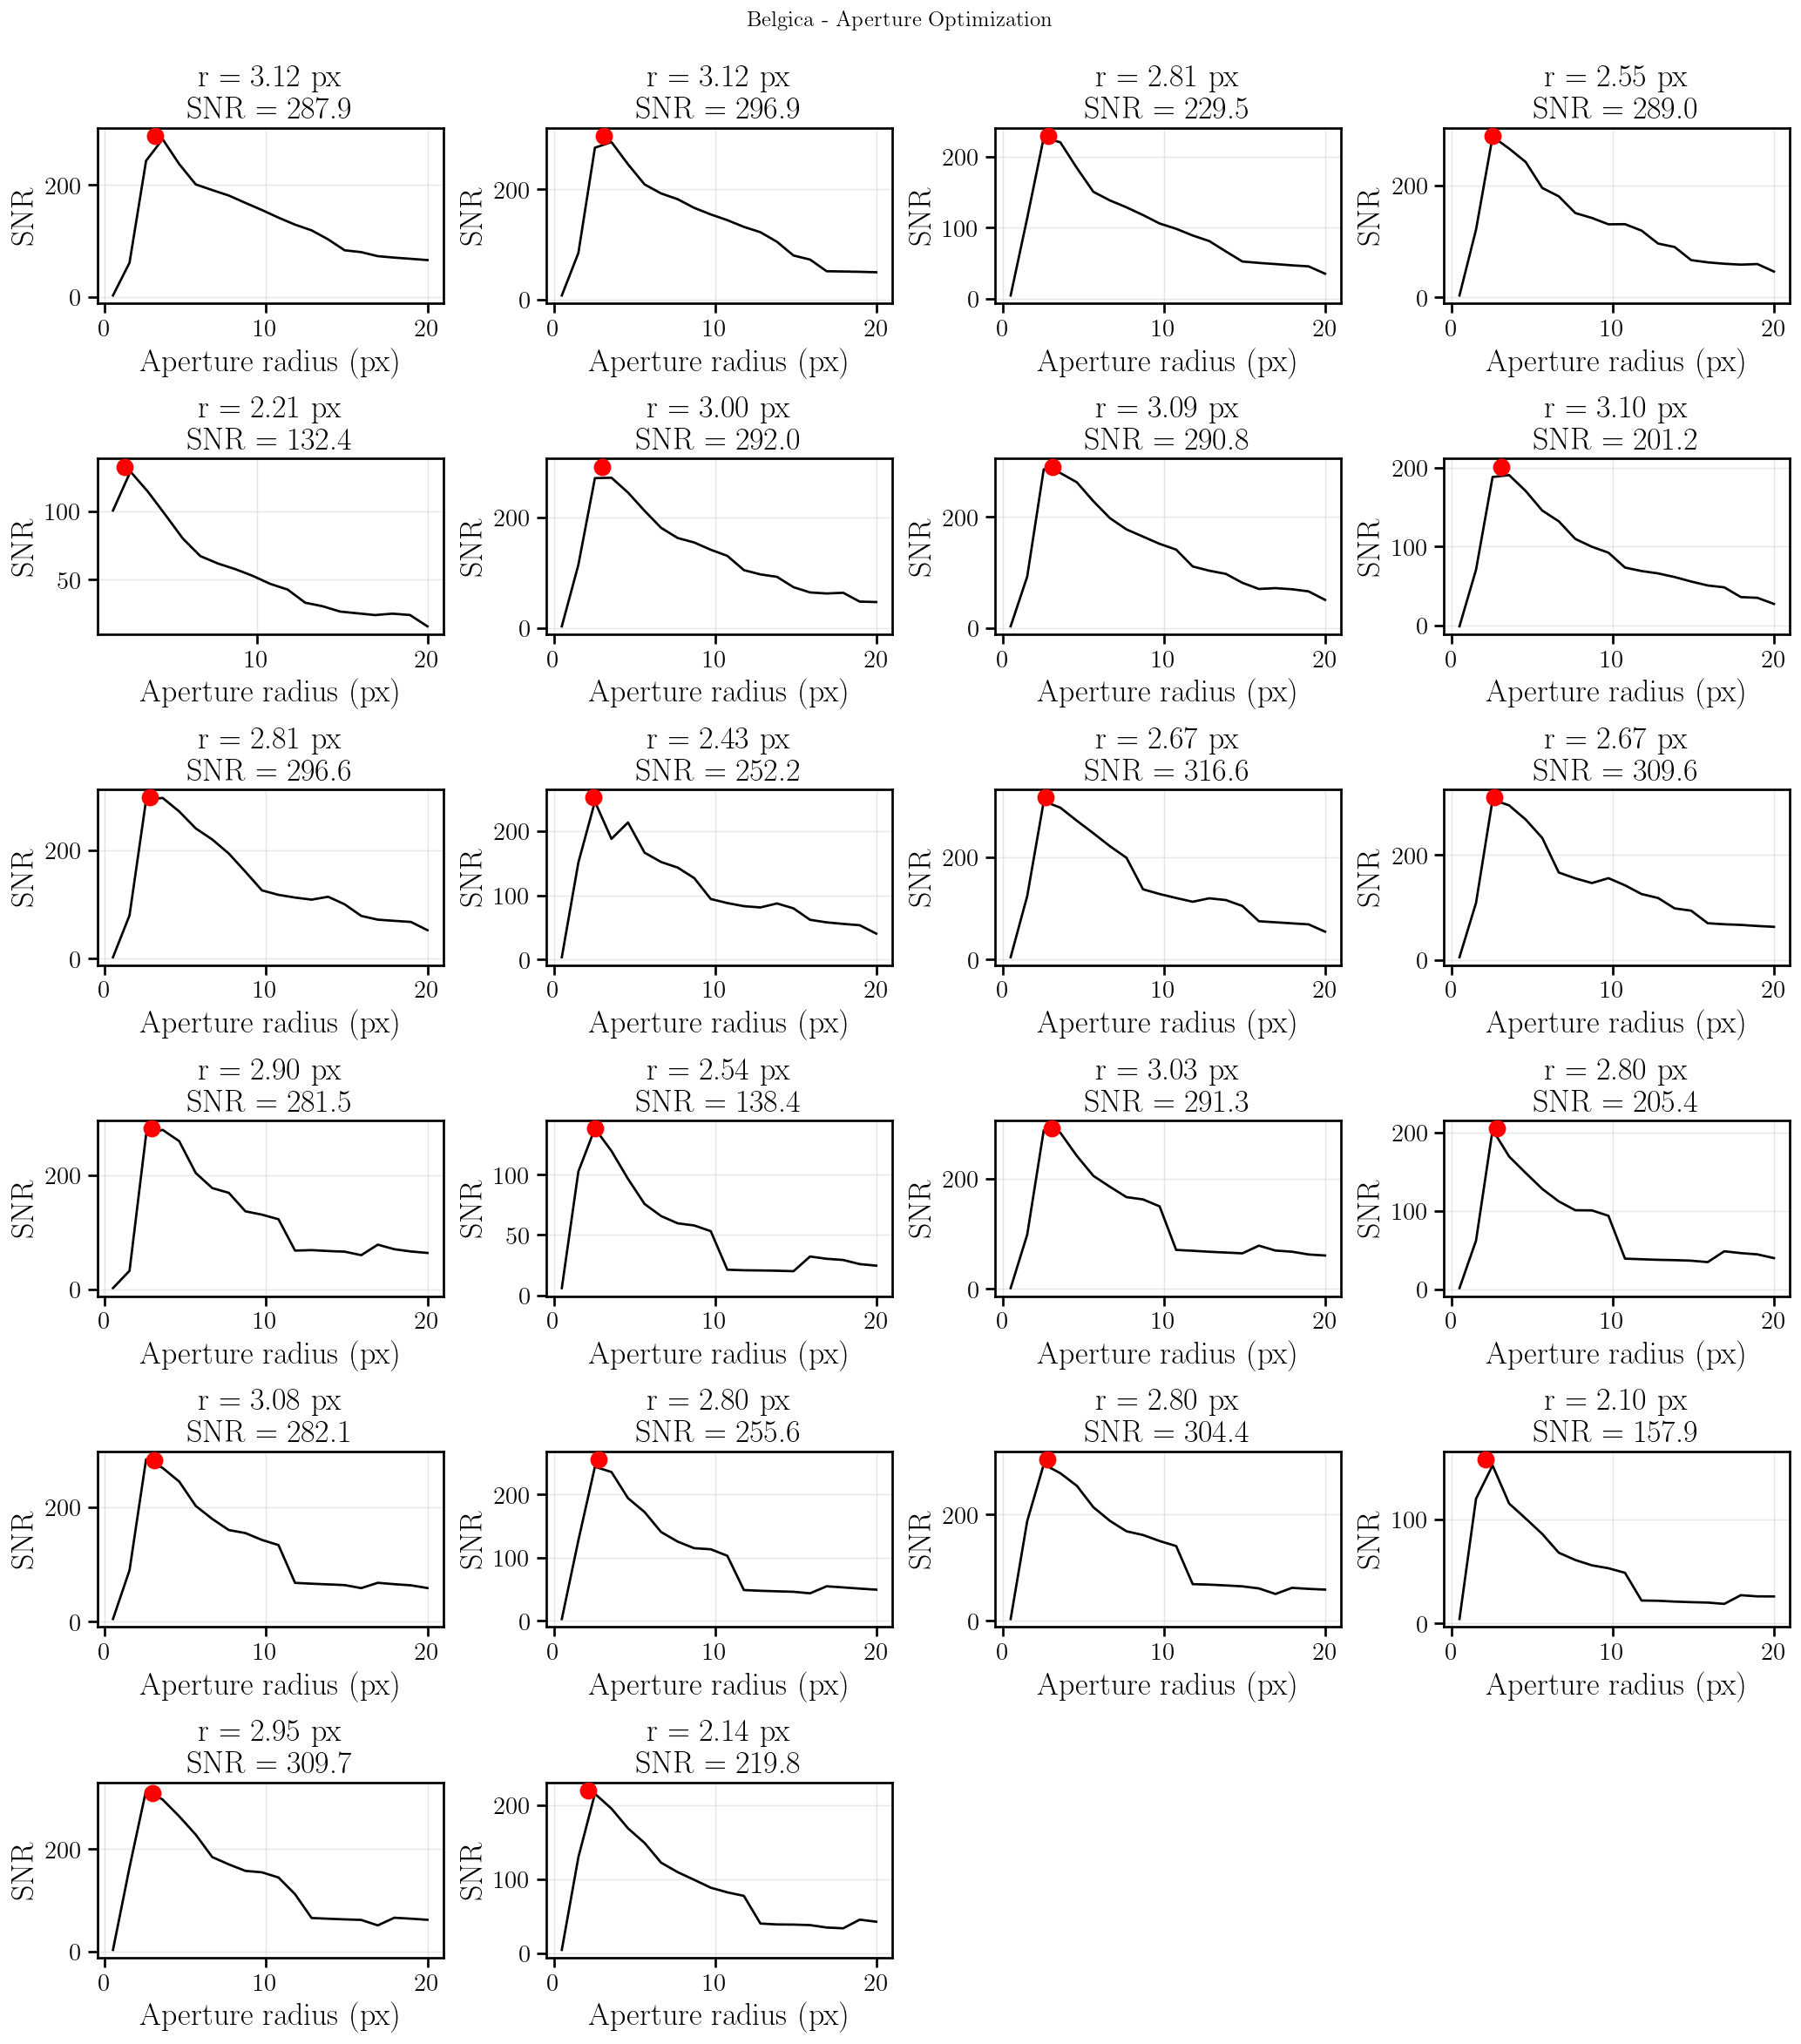

In [11]:
def optimize_apertures(data, locations, title="Aperture Optimization"):
    """
    Optimize aperture radius for each image to maximize SNR.
    
    Parameters:
    -----------
    data : list
        List of image arrays
    locations : list
        List of (x, y) pixel coordinates
    title : str
        Title for the plot
    
    Returns:
    --------
    list : Optimal aperture radii for each image
    """
    n_images = len(data)
    ncols = min(4, n_images)
    nrows = (n_images + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    if n_images == 1:
        axs = [axs]
    else:
        axs = axs.flatten() if nrows > 1 else axs
    
    optimal_radii = []
    
    for i, (d, loc, ax) in enumerate(zip(data, locations, axs)):
        def ap_opt(r):
            if r <= 0:  # Safety check
                return 1e10
            an1 = 2 * r
            an2 = 3 * r
            ap = CircularAperture(loc, r=r)
            an = CircularAnnulus(loc, r_in=an1, r_out=an2)
            return -snr(d, ap, an)
        
        # Rough search
        aps = np.linspace(0.5, 20, 20)
        rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]
        
        # Fine optimization with safe bounds
        lower_bound = max(0.5, rough_peak - 2)  # Ensure lower bound is positive
        upper_bound = rough_peak + 2
        res = minimize_scalar(ap_opt, bounds=(lower_bound, upper_bound), method='bounded')
        optimal_radii.append(res.x)
        
        # Plot
        ax.plot(aps, [-ap_opt(ap) for ap in aps], c="k")
        ax.scatter(res.x, -res.fun, c="r", s=100, zorder=5)
        ax.set_title(f"r = {res.x:.2f} px\nSNR = {-res.fun:.1f}")
        ax.set_xlabel("Aperture radius (px)")
        ax.set_ylabel("SNR")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(data), len(axs)):
        axs[i].axis('off')
    
    fig.suptitle(title, fontsize=14, y=1.00)
    fig.tight_layout()
    plt.show()
    
    return optimal_radii

print("Optimizing apertures for Standard Star 1...")
optims1 = optimize_apertures(data1, locs1, "Standard Star 1 - Aperture Optimization")

print("\nOptimizing apertures for Standard Star 2...")
optims2 = optimize_apertures(data2, locs2, "Standard Star 2 - Aperture Optimization")

print("\nOptimizing apertures for Standard Star 3...")
optims3 = optimize_apertures(data3, locs3, "Standard Star 3 - Aperture Optimization")

print(f"\nOptimizing apertures for {asteroid_name}...")
optims_asteroid = optimize_apertures(data_asteroid, locs_asteroid, f"{asteroid_name} - Aperture Optimization")

## Perform Photometry

In [39]:
def perform_photometry(codes, data, locations, optimal_radii, data_dir, object_name="object"):
    """
    Perform aperture photometry on all images.
    
    Parameters:
    -----------
    codes : list
        Image codes
    data : list
        Image data arrays
    locations : list
        Source pixel coordinates
    optimal_radii : list
        Optimized aperture radii
    data_dir : str or dict
        Directory or dict of directories containing FITS files
    object_name : str
        Name of object for display
    
    Returns:
    --------
    dict : Photometry results keyed by image code
    """
    results = {}
    
    for i, c in enumerate(codes):
        # Determine data directory
        if isinstance(data_dir, dict):
            dir_path = data_dir.get(c, data_dir['default'])
        else:
            dir_path = data_dir
        
        # Load image
        with fits.open(f'{dir_path}/{c}.fits') as file:
            hdr = file[0].header.copy()
            image = file[0].data
        
        # Define apertures
        r_ap = optimal_radii[i]
        r_sky_in = r_ap * 1.5
        r_sky_out = r_ap * 2.0
        
        ap = CircularAperture(locations[i], r=r_ap)
        an = CircularAnnulus(locations[i], r_in=r_sky_in, r_out=r_sky_out)
        
        # Sky background
        sky_phot = aperture_photometry(image, an)
        sky_area = np.pi * (r_sky_out**2 - r_sky_in**2)
        sky_flux = sky_phot['aperture_sum'].value
        mean_sky = sky_flux / sky_area
        
        # Source photometry
        src_phot = aperture_photometry(image - mean_sky, ap)
        src_flux = src_phot['aperture_sum'].value
        
        # Calculate magnitude
        exposure = hdr['EXPOSURE']
        norm_flux = src_flux / exposure
        magnitude = flux_to_mag(norm_flux)
        mag_error = error_in_mag(src_flux, sky_flux)
        
        # Get filter and airmass
        filt = normalize_filter_name(hdr.get('FILTER', 'UNKNOWN'), filter_map)
        airmass = get_airmass(hdr)
        
        # Store results
        results[c] = {
            'magnitude': magnitude,
            'error': mag_error,
            'filter': filt,
            'airmass': airmass,
            'exposure': exposure,
            'flux': src_flux,
            'norm_flux': norm_flux
        }
        
        print(f'{object_name} image {c}: mag = {magnitude[0]:.4f} +/- {abs(mag_error[0]):.4f}, '
              f'filter = {filt}, airmass = {airmass:.3f}')
    
    return results

In [40]:
print("=" * 60)
print("STANDARD STAR 1 PHOTOMETRY")
print("=" * 60)
ss1_results = perform_photometry(
    codes1, data1, locs1, optims1,
    f'{direc}/Reduced_data_day3',
    object_name="SS1"
)

print("\n" + "=" * 60)
print("STANDARD STAR 2 PHOTOMETRY")
print("=" * 60)
ss2_results = perform_photometry(
    codes2, data2, locs2, optims2,
    f'{direc}/Reduced_data_day3',
    object_name="SS2"
)

print("\n" + "=" * 60)
print("STANDARD STAR 3 PHOTOMETRY")
print("=" * 60)
ss3_results = perform_photometry(
    codes3, data3, locs3, optims3,
    f'{direc}/Reduced_data_day3',
    object_name="SS3"
)

print("\n" + "=" * 60)
print(f"{asteroid_name.upper()} PHOTOMETRY")
print("=" * 60)
asteroid_results = perform_photometry(
    asteroid_codes, data_asteroid, locs_asteroid, optims_asteroid,
    asteroid_data_dirs,
    object_name=asteroid_name
)

STANDARD STAR 1 PHOTOMETRY
SS1 image 167861: mag = -9.8610 +/- 0.0022, filter = R, airmass = 1.257
SS1 image 167863: mag = -8.7335 +/- 0.0036, filter = B, airmass = 1.262
SS1 image 167866: mag = -9.4058 +/- 0.0027, filter = I, airmass = 1.292
SS1 image 167868: mag = -9.4334 +/- 0.0027, filter = I, airmass = 1.307
SS1 image 167869: mag = -8.7118 +/- 0.0036, filter = B, airmass = 1.310
SS1 image 167870: mag = -8.7140 +/- 0.0036, filter = B, airmass = 1.312
SS1 image 167871: mag = -9.5377 +/- 0.0025, filter = V, airmass = 1.315
SS1 image 167872: mag = -9.5325 +/- 0.0025, filter = V, airmass = 1.317
SS1 image 167874: mag = -9.8520 +/- 0.0022, filter = R, airmass = 1.328
SS1 image 167875: mag = -9.8511 +/- 0.0022, filter = R, airmass = 1.330
SS1 image 167876: mag = -9.3923 +/- 0.0027, filter = I, airmass = 1.332
SS1 image 167877: mag = -9.5355 +/- 0.0025, filter = V, airmass = 1.335

STANDARD STAR 2 PHOTOMETRY
SS2 image 167879: mag = -9.3195 +/- 0.0028, filter = V, airmass = 1.148
SS2 image

## Calibration

Calculate extinction coefficients and zero points for each filter.

In [41]:
def calculate_extinction_and_zeropoint(results, true_mags, star_name="Star", plot=True):
    """
    Calculate extinction coefficient and zero point for each filter.
    
    Parameters:
    -----------
    results : dict
        Photometry results
    true_mags : dict
        Dictionary of true magnitudes per filter, e.g. {'B': 10.5, 'V': 9.8, 'R': 9.2, 'I': 8.7}
    star_name : str
        Name of star for printing
    plot : bool
        Whether to create plots of magnitude vs airmass
    
    Returns:
    --------
    tuple : (extinction_dict, zeropoint_dict)
    """
    # Organize by filter
    by_filter = {}
    for code, data in results.items():
        filt = data['filter']
        if filt not in by_filter:
            by_filter[filt] = {'mags': [], 'airmass': []}
        by_filter[filt]['mags'].append(data['magnitude'][0])
        by_filter[filt]['airmass'].append(data['airmass'])
    
    extinction = {}
    zeropoint = {}
    
    # Create figure if plotting
    if plot and len(by_filter) > 0:
        n_filters = len([f for f in by_filter.keys() if f in true_mags and true_mags[f] is not None])
        if n_filters > 0:
            fig, axes = plt.subplots(1, n_filters, figsize=(5*n_filters, 4))
            if n_filters == 1:
                axes = [axes]
            ax_idx = 0
    
    for filt, data in by_filter.items():
        mags = np.array(data['mags'])
        airmass = np.array(data['airmass'])
        
        if filt not in true_mags or true_mags[filt] is None:
            print(f"  {star_name} {filt} band: No true magnitude available, skipping")
            continue
        
        m_true = true_mags[filt]
        
        if len(mags) > 1:
            coeffs = np.polyfit(airmass, mags, 1)
            k = np.abs(coeffs[0] )          # extinction coefficient (slope)
            intercept = coeffs[1]   # intercept at X=0
            
            # ZP = intercept - m_true
            zp = intercept - m_true
            
            print(f"  {star_name} {filt} band: k = {k:.4f}, ZP = {zp:.4f} (m_true = {m_true:.4f})")
            
            # Plot
            if plot:
                ax = axes[ax_idx]
                ax.plot(airmass, mags, 'o', label='Observations')
                airmass_fit = np.linspace(airmass.min(), airmass.max(), 100)
                mags_fit = k * airmass_fit + intercept
                ax.plot(airmass_fit, mags_fit, 'r-', label=f'Fit: k={k:.4f}')
                ax.set_xlabel('Airmass')
                ax.set_ylabel('Instrumental Magnitude')
                ax.set_title(f'{star_name} - {filt} band')
                ax.legend()
                ax.grid(True, alpha=0.3)
                ax_idx += 1
        else:
            k = 0.0
            zp = mags[0] - m_true
            print(f"  {star_name} {filt} band: single observation, k = 0, ZP = {zp:.4f}")
            
            # Plot single point
            if plot:
                ax = axes[ax_idx]
                ax.plot(airmass, mags, 'o', markersize=10, label='Single observation')
                ax.set_xlabel('Airmass')
                ax.set_ylabel('Instrumental Magnitude')
                ax.set_title(f'{star_name} - {filt} band (single obs)')
                ax.legend()
                ax.grid(True, alpha=0.3)
                ax_idx += 1
        
        extinction[filt] = k
        zeropoint[filt] = zp
    
    if plot and len(by_filter) > 0 and ax_idx > 0:
        plt.tight_layout()
        plt.show()
    
    return extinction, zeropoint

Now, we need to obtain true magnitudes in each filter.


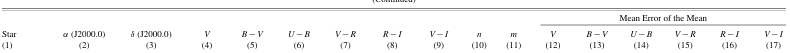

SS1: 


SS2: 


SS3:



From Landolt, Arlo U. ‘UBVRI Photometric Standard Stars around the Sky at +50 Deg Declination’. The Astronomical Journal 146 (November 2013): 131. https://doi.org/10.1088/0004-6256/146/5/131.
For each filter, we may calculate true magnitudes as:

$B = V + (B-V)$

$R = V - (V-R)$

$I = V - (V-R) - (R-I)$

EXTINCTION AND ZERO POINTS

Standard Star 1:
  SS1 R band: k = 0.1315, ZP = -21.0413 (m_true = 11.0150)
  SS1 B band: k = 0.4173, ZP = -21.4831 (m_true = 12.2230)
  SS1 I band: k = 0.4594, ZP = -20.5306 (m_true = 10.5180)
  SS1 V band: k = 0.0035, ZP = -20.9936 (m_true = 11.4630)


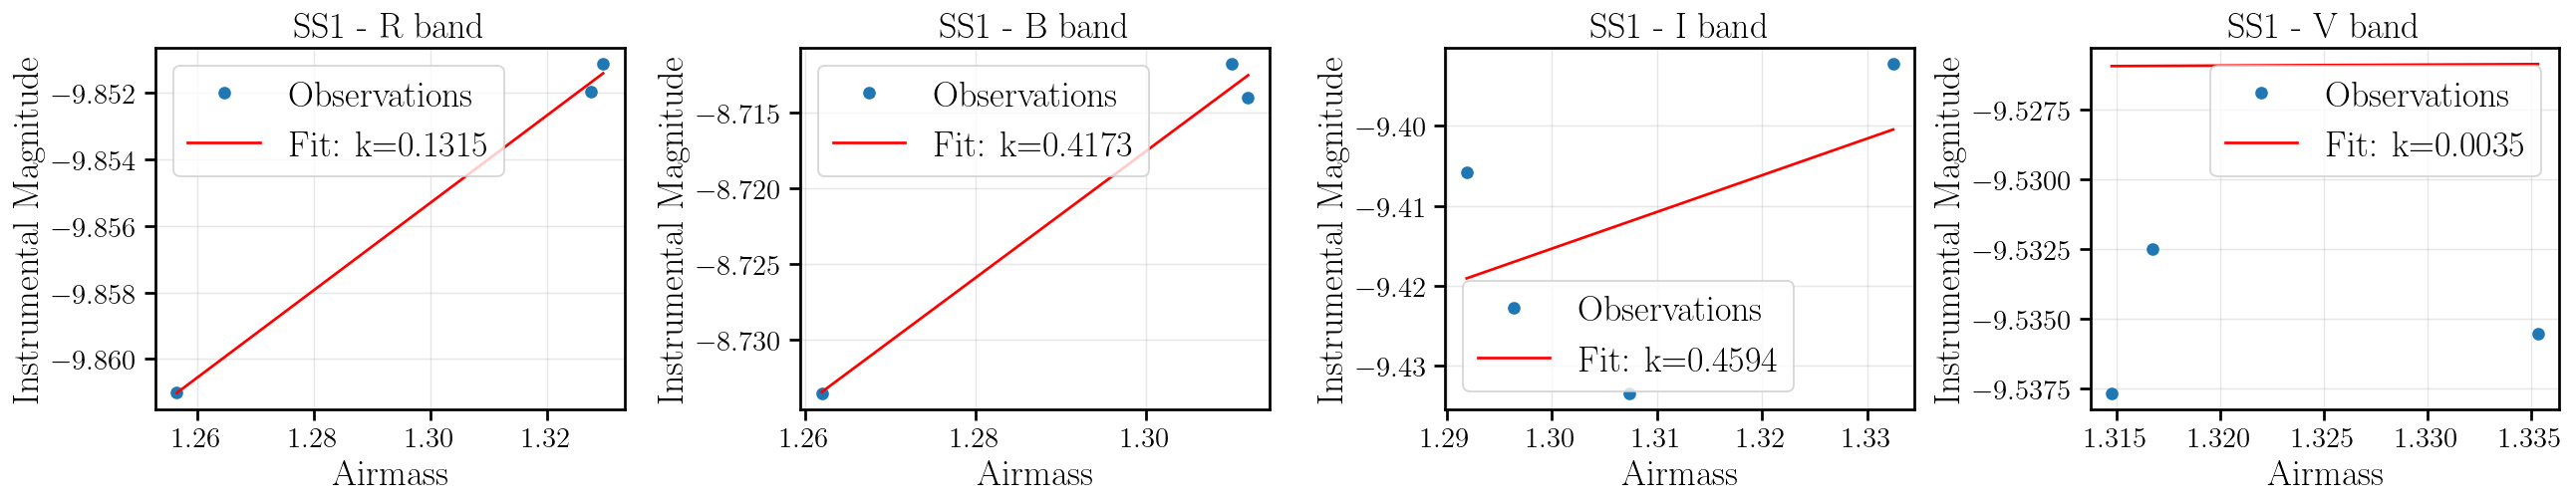


Standard Star 2:
  SS2 V band: k = 0.3130, ZP = -21.3754 (m_true = 11.7140)
  SS2 B band: k = 0.0794, ZP = -21.0097 (m_true = 11.9900)
  SS2 R band: k = 0.0046, ZP = -20.8896 (m_true = 11.5680)
  SS2 I band: k = 0.4929, ZP = -19.3186 (m_true = 11.4030)


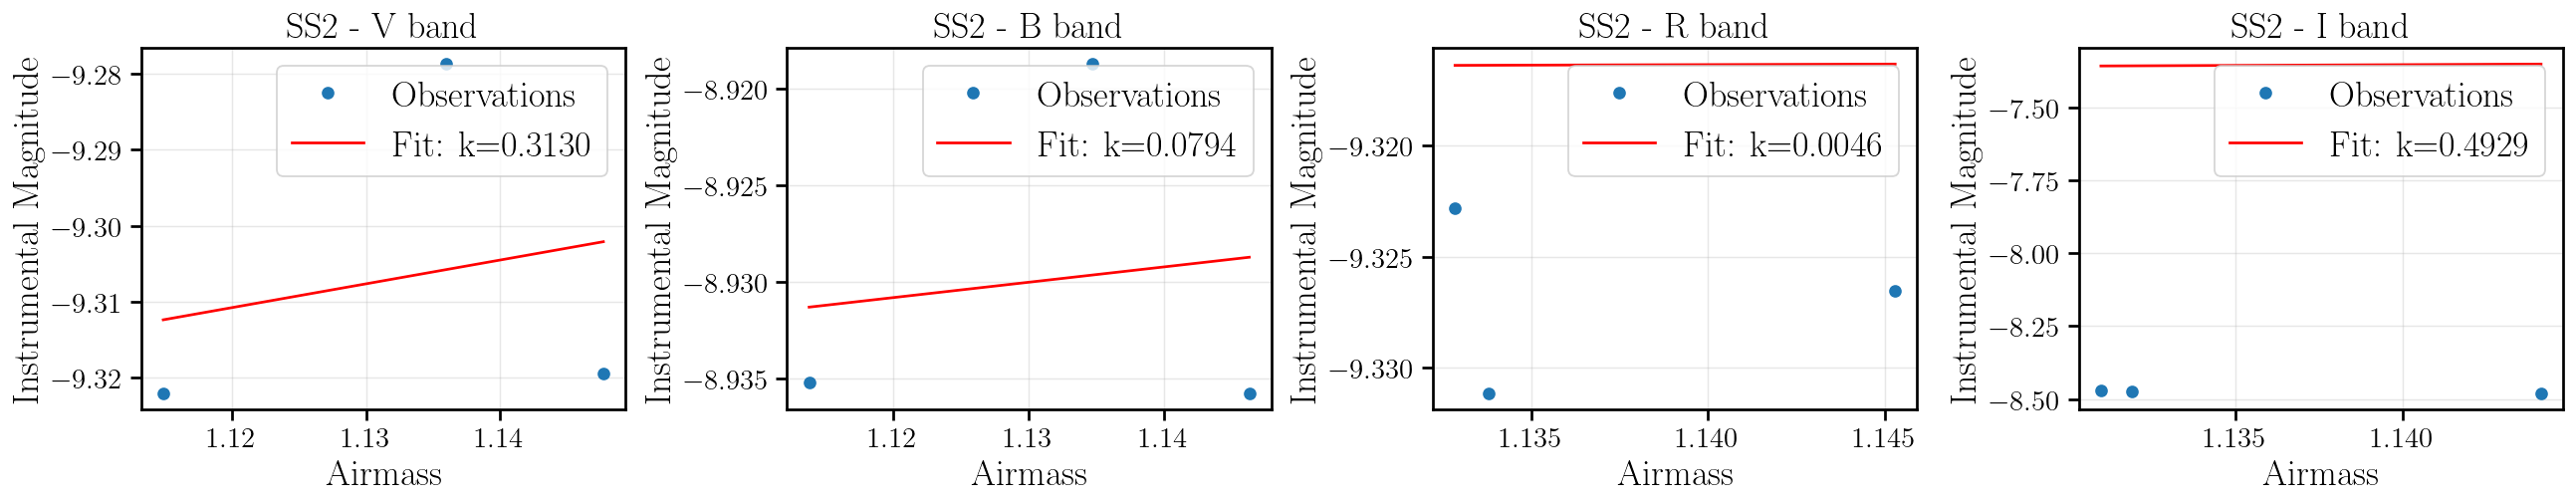


Standard Star 3:
  SS3 V band: k = 0.8408, ZP = -22.1952 (m_true = 10.6580)
  SS3 B band: k = 0.0787, ZP = -20.8071 (m_true = 11.0330)
  SS3 R band: k = 0.5624, ZP = -21.6866 (m_true = 10.4560)
  SS3 I band: k = 0.3929, ZP = -19.3734 (m_true = 10.2430)


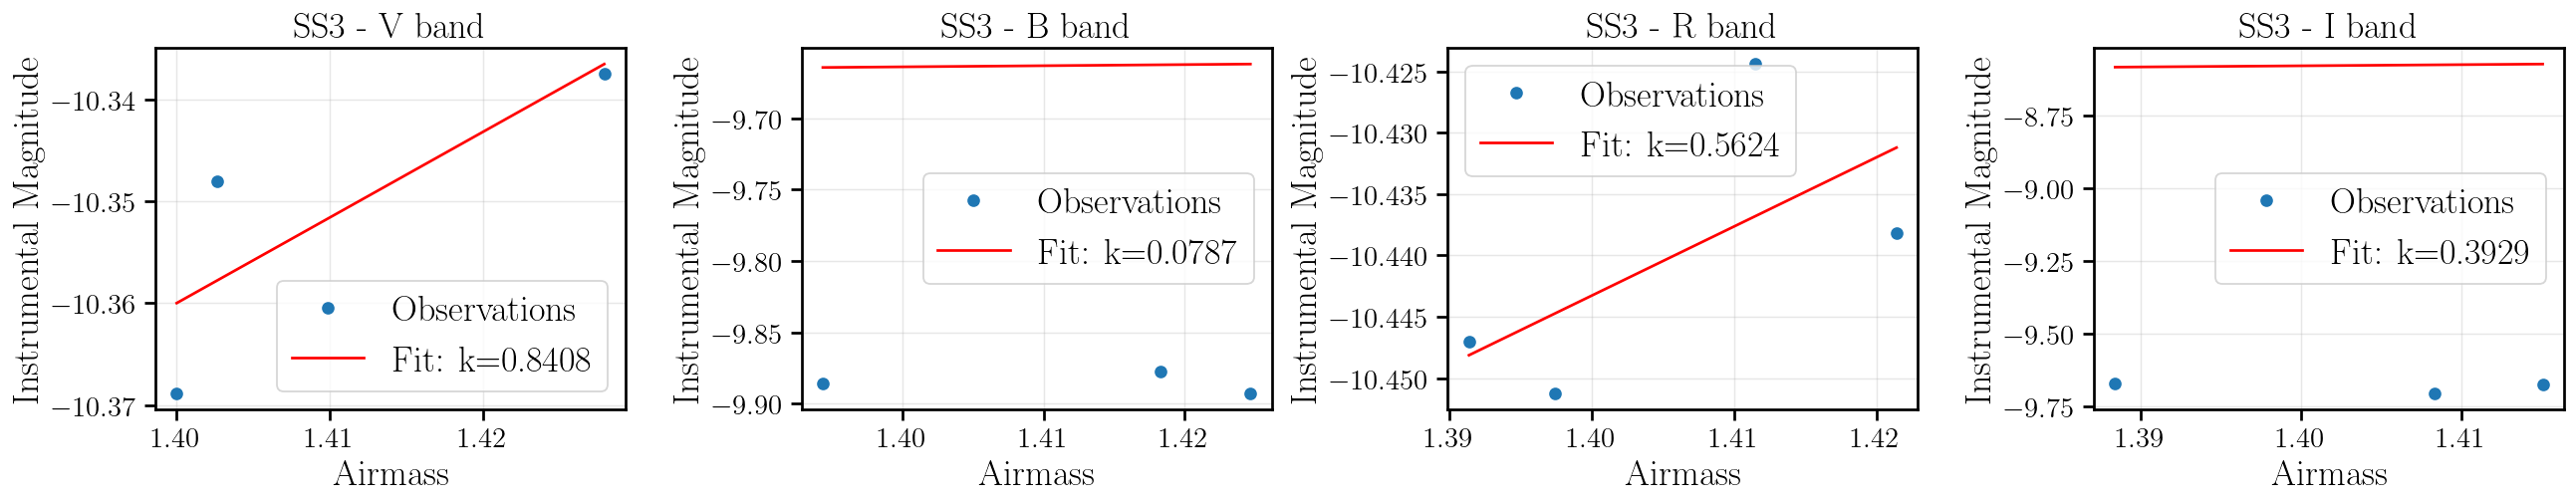


COMBINED CALIBRATION
  B band: k = 0.1918 +/- 0.1595, ZP = -21.1000 +/- 0.2832 (from 3 stars)
  I band: k = 0.4484 +/- 0.0416, ZP = -19.7409 +/- 0.5588 (from 3 stars)
  R band: k = 0.2328 +/- 0.2387, ZP = -21.2058 +/- 0.3455 (from 3 stars)
  V band: k = 0.3858 +/- 0.3457, ZP = -21.5214 +/- 0.5013 (from 3 stars)


In [42]:
# These I calculated by hand
ss1_true_mags = {'B': 12.223, 'V': 11.463, 'R': 11.015, 'I': 10.518 }
ss2_true_mags = {'B': 11.990, 'V': 11.714, 'R': 11.568, 'I': 11.403}
ss3_true_mags = {'B': 11.0330, 'V': 10.6580, 'R': 10.4560, 'I': 10.2430}

print("=" * 60)
print("EXTINCTION AND ZERO POINTS")
print("=" * 60)

print("\nStandard Star 1:")
ss1_extinction, ss1_zeropoints = calculate_extinction_and_zeropoint(ss1_results, ss1_true_mags, "SS1")

print("\nStandard Star 2:")
ss2_extinction, ss2_zeropoints = calculate_extinction_and_zeropoint(ss2_results, ss2_true_mags, "SS2")

print("\nStandard Star 3:")
ss3_extinction, ss3_zeropoints = calculate_extinction_and_zeropoint(ss3_results, ss3_true_mags, "SS3")

# Average extinction and zero points across all three standard stars
print("\n" + "=" * 60)
print("COMBINED CALIBRATION")
print("=" * 60)

all_filters = set(list(ss1_extinction.keys()) + list(ss2_extinction.keys()) + list(ss3_extinction.keys()))

combined_extinction = {}
combined_zeropoints = {}

for filt in sorted(all_filters):
    k_values = []
    zp_values = []
    
    for ext, zp in [(ss1_extinction, ss1_zeropoints), 
                    (ss2_extinction, ss2_zeropoints), 
                    (ss3_extinction, ss3_zeropoints)]:
        if filt in ext:
            k_values.append(ext[filt])
            zp_values.append(zp[filt])
    
    combined_extinction[filt] = np.mean(k_values)
    combined_zeropoints[filt] = np.mean(zp_values)
    
    print(f"  {filt} band: k = {combined_extinction[filt]:.4f} +/- {np.std(k_values):.4f}, "
          f"ZP = {combined_zeropoints[filt]:.4f} +/- {np.std(zp_values):.4f} (from {len(k_values)} stars)")

## Apply calibration to find true colours of Belgica

I'm scared

In [43]:
def apply_calibration(results, combined_extinction, combined_zeropoints, object_name="Object"):
    """
    Apply extinction correction and zero points to get calibrated magnitudes.
    
    Parameters:
    -----------
    results : dict
        Photometry results from asteroid
    combined_extinction : dict
        Extinction coefficients per filter
    combined_zeropoints : dict
        Zero points per filter
    object_name : str
        Name of object for printing
    
    Returns:
    --------
    dict : Calibrated magnitudes per filter
    """
    # Organize by filter
    by_filter = {}
    for code, data in results.items():
        filt = data['filter']
        if filt not in by_filter:
            by_filter[filt] = {'inst_mags': [], 'airmass': [], 'cal_mags': []}
        
        inst_mag = data['magnitude'][0]
        airmass = data['airmass']
        
        # Apply extinction correction and zero point
        # m_true = m_inst - k*X - ZP
        if filt in combined_extinction and filt in combined_zeropoints:
            k = combined_extinction[filt]
            zp = combined_zeropoints[filt]
            cal_mag = inst_mag - k * airmass - zp
            
            by_filter[filt]['inst_mags'].append(inst_mag)
            by_filter[filt]['airmass'].append(airmass)
            by_filter[filt]['cal_mags'].append(cal_mag)
    
    # Calculate mean magnitudes per filter
    calibrated_mags = {}
    calibrated_mags_err = {}
    print(f"\n{object_name} Calibrated Magnitudes:")
    for filt in sorted(by_filter.keys()):
        cal_mags = np.array(by_filter[filt]['cal_mags'])
        mean_mag = np.mean(cal_mags)
        std_mag = np.std(cal_mags)
        
        calibrated_mags[filt] = mean_mag
        calibrated_mags_err[filt] = std_mag
        print(f"  {filt}: {mean_mag:.4f} ± {std_mag:.4f} (from {len(cal_mags)} observations)")
    
    return calibrated_mags, calibrated_mags_err

# Apply calibration to asteroid
asteroid_calibrated_mags,asteroid_calibrated_mags_err = apply_calibration(
    asteroid_results, 
    combined_extinction, 
    combined_zeropoints, 
    object_name=asteroid_name
)

# Now calculate colors and the corresponding errors 
# Combine errors by adding them in quadrature

print(f"\n{asteroid_name} Colors:")
if 'B' in asteroid_calibrated_mags and 'V' in asteroid_calibrated_mags:
    bv = asteroid_calibrated_mags['B'] - asteroid_calibrated_mags['V']
    bv_err = np.sqrt((asteroid_calibrated_mags_err['B'])**2 + (asteroid_calibrated_mags_err['V'])**2)
    print(f"  B-V: {bv:.4f} +/- {bv_err:.4f}")

if 'V' in asteroid_calibrated_mags and 'R' in asteroid_calibrated_mags:
    vr = asteroid_calibrated_mags['V'] - asteroid_calibrated_mags['R']
    vr_err = np.sqrt((asteroid_calibrated_mags_err['V'])**2 + (asteroid_calibrated_mags_err['R'])**2)
    print(f"  V-R: {vr:.4f} +/- {vr_err:.4f}")

if 'R' in asteroid_calibrated_mags and 'I' in asteroid_calibrated_mags:
    ri = asteroid_calibrated_mags['R'] - asteroid_calibrated_mags['I']
    ri_err = np.sqrt((asteroid_calibrated_mags_err['R'])**2 + (asteroid_calibrated_mags_err['I'])**2)
    print(f"  R-I: {ri:.4f} +/- {ri_err:.4f}")

if 'V' in asteroid_calibrated_mags and 'I' in asteroid_calibrated_mags:
    vi = asteroid_calibrated_mags['V'] - asteroid_calibrated_mags['I']
    vi_err = np.sqrt((asteroid_calibrated_mags_err['V'])**2 + (asteroid_calibrated_mags_err['I'])**2)
    print(f"  V-I: {vi:.4f} +/- {vi_err:.4f}")


Belgica Calibrated Magnitudes:
  B: 15.7515 ± 0.0847 (from 3 observations)
  I: 13.1991 ± 0.0734 (from 3 observations)
  R: 14.3726 ± 0.0575 (from 13 observations)
  V: 14.8604 ± 0.0303 (from 3 observations)

Belgica Colors:
  B-V: 0.8911 +/- 0.0900
  V-R: 0.4878 +/- 0.0650
  R-I: 1.1735 +/- 0.0933
  V-I: 1.6614 +/- 0.0794


## Now, let's get the size

### Calculate the ugriz colours + errors

In [44]:
def calculate_sdss_colors(bv, vr, ri):
    """
    Convert Johnson-Cousins colors to SDSS colors.
    
    Parameters:
    -----------
    bv : float
        B-V color
    vr : float
        V-R color
    ri : float
        R-I color
    
    Returns:
    --------
    dict : SDSS colors (g-r, r-i, r-z)
    """
    # Equation (2): g - r = 0.278(+/- 0.016) * (B-V) + 1.321(+/- 0.030) * (V-R) - 0.219
    g_minus_r = 0.278 * bv + 1.321 * vr - 0.219
    
    # Equation (3): r - i = 1.070(+/- 0.009) * (R-I) - 0.228
    r_minus_i = 1.070 * ri - 0.228
    
    # Equation (4): r - z = 1.607(+/- 0.012) * (R-I) - 0.371
    r_minus_z = 1.607 * ri - 0.371
    
    return {
        'g-r': g_minus_r,
        'r-i': r_minus_i,
        'r-z': r_minus_z
    }

def calculate_sdss_colors_with_errors(bv, vr, ri, bv_err, vr_err, ri_err):
    """
    Convert Johnson-Cousins colors to SDSS colors with error propagation.
    
    Parameters:
    -----------
    bv, vr, ri : float
        B-V, V-R, R-I colors
    bv_err, vr_err, ri_err : float
        Uncertainties in colors
    
    Returns:
    --------
    dict : SDSS colors with errors
    """
    colors = calculate_sdss_colors(bv, vr, ri)
    
    # Error propagation (assuming independent uncertainties)
    # For g-r: σ² = (0.278*σ_BV)² + (1.321*σ_VR)² + σ_cal² where σ_cal includes calibration errors
    gr_err = np.sqrt((0.278 * bv_err)**2 + (1.321 * vr_err)**2 + 0.016**2 + 0.030**2)
    
    # For r-i: σ² = (1.070*σ_RI)² + σ_cal²
    ri_err_sdss = np.sqrt((1.070 * ri_err)**2 + 0.009**2)
    
    # For r-z: σ² = (1.607*σ_RI)² + σ_cal²
    rz_err = np.sqrt((1.607 * ri_err)**2 + 0.012**2)
    
    return {
        'g-r': (colors['g-r'], gr_err),
        'r-i': (colors['r-i'], ri_err_sdss),
        'r-z': (colors['r-z'], rz_err)
    }

# Calculate SDSS colors for Belgica
print("\n" + "=" * 60)
print("SDSS COLOR TRANSFORMATIONS")
print("=" * 60)
sdss_colors = calculate_sdss_colors_with_errors(bv, vr, ri, bv_err, vr_err, ri_err)

print(f"\nBelgica SDSS colors:")
for color, (value, error) in sdss_colors.items():
    print(f"  {color}: {value:.4f} ± {error:.4f}")



SDSS COLOR TRANSFORMATIONS

Belgica SDSS colors:
  g-r: 0.6731 ± 0.0957
  r-i: 1.0277 ± 0.1002
  r-z: 1.5149 ± 0.1503


### Find the spectral type based on the table below 

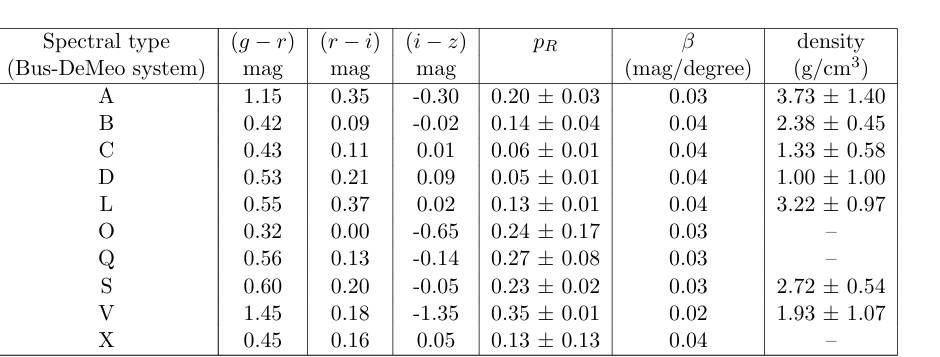

In [47]:
print("\n" + "=" * 60)
print("SPECTRAL TYPE CLASSIFICATION")
print("=" * 60)

# Reference spectral type colors from the table above
spectral_types = {
    'A': {'g-r': 1.15, 'r-i': 0.35, 'i-z': -0.30, 'pR': 0.20, 'pR_err': 0.03, 'beta': 0.03, 'density': 3.73, 'density_err': 1.40},
    'B': {'g-r': 0.42, 'r-i': 0.09, 'i-z': -0.02, 'pR': 0.14, 'pR_err': 0.04, 'beta': 0.04, 'density': 2.38, 'density_err': 0.45},
    'C': {'g-r': 0.43, 'r-i': 0.11, 'i-z': 0.01, 'pR': 0.06, 'pR_err': 0.01, 'beta': 0.04, 'density': 1.33, 'density_err': 0.58},
    'D': {'g-r': 0.53, 'r-i': 0.21, 'i-z': 0.09, 'pR': 0.05, 'pR_err': 0.01, 'beta': 0.04, 'density': 1.00, 'density_err': 1.00},
    'L': {'g-r': 0.55, 'r-i': 0.37, 'i-z': 0.02, 'pR': 0.13, 'pR_err': 0.01, 'beta': 0.04, 'density': 3.22, 'density_err': 0.97},
    'O': {'g-r': 0.32, 'r-i': 0.00, 'i-z': -0.65, 'pR': 0.24, 'pR_err': 0.17, 'beta': 0.03, 'density': None},
    'Q': {'g-r': 0.56, 'r-i': 0.13, 'i-z': -0.14, 'pR': 0.27, 'pR_err': 0.08, 'beta': 0.03, 'density': None},
    'S': {'g-r': 0.60, 'r-i': 0.20, 'i-z': -0.05, 'pR': 0.23, 'pR_err': 0.02, 'beta': 0.03, 'density': 2.72, 'density_err': 0.54},
    'V': {'g-r': 1.45, 'r-i': 0.18, 'i-z': -1.35, 'pR': 0.35, 'pR_err': 0.01, 'beta': 0.02, 'density': 1.93, 'density_err': 1.07},
    'X': {'g-r': 0.45, 'r-i': 0.16, 'i-z': 0.05, 'pR': 0.13, 'pR_err': 0.13, 'beta': 0.04, 'density': None},
}

def classify_spectral_type(measured_colors, spectral_types):
    """
    Classify asteroid spectral type based on measured SDSS colors.
    Uses Euclidean distance in color space (weighted by available colors).
    
    Parameters:
    -----------
    measured_colors : dict
        Dictionary with 'g-r', 'r-i', 'r-z' (or 'i-z') values
    spectral_types : dict
        Reference spectral type data
    
    Returns:
    --------
    best_type : str
        Best matching spectral type
    distances : dict
        Distance to each spectral type
    """
    # Calculate i-z from r-z if not provided
    if 'i-z' not in measured_colors and 'r-z' in measured_colors:
        ri_val = measured_colors['r-i'][0]
        measured_colors['i-z'] = (0.537 * (ri_val + 0.228) / 1.070 - 0.143, 0.05)  # rough error
    
    distances = {}
    for spec_type, ref_colors in spectral_types.items():
        # Calculate Euclidean distance in color space
        dist_sq = 0
        count = 0
        
        for color in ['g-r', 'r-i', 'i-z']:
            if color in measured_colors:
                meas_val = measured_colors[color][0]
                ref_val = ref_colors[color]
                dist_sq += (meas_val - ref_val)**2
                count += 1
        
        if count > 0:
            distances[spec_type] = np.sqrt(dist_sq / count)
        else:
            distances[spec_type] = np.inf
    
    best_type = min(distances, key=distances.get)
    return best_type, distances

# Classify the asteroid
best_type, distances = classify_spectral_type(sdss_colors, spectral_types)

print(f"\nMeasured SDSS colors for Belgica:")
for color, (value, error) in sdss_colors.items():
    print(f"  {color}: {value:.3f} ± {error:.3f}")

print(f"\nSpectral type distances:")
sorted_types = sorted(distances.items(), key=lambda x: x[1])
for spec_type, dist in sorted_types[:5]:  # Show top 5 matches
    print(f"  {spec_type}: {dist:.4f}")

print(f"\n{'*' * 60}")
print(f"BEST MATCH: Type {best_type}")
print(f"{'*' * 60}")

# Get properties for best matching type
selected_properties = spectral_types[best_type]
print(f"\nProperties of Type {best_type} asteroids:")
print(f"  Geometric albedo (pR): {selected_properties['pR']:.3f} ± {selected_properties['pR_err']:.3f}")
print(f"  Phase coefficient (β): {selected_properties['beta']:.3f} mag/degree")
if selected_properties['density'] is not None:
    print(f"  Typical density: {selected_properties['density']:.2f} ± {selected_properties['density_err']:.2f} g/cm³")
else:
    print(f"  Typical density: Not available")


SPECTRAL TYPE CLASSIFICATION

Measured SDSS colors for Belgica:
  g-r: 0.673 ± 0.096
  r-i: 1.028 ± 0.100
  r-z: 1.515 ± 0.150
  i-z: 0.487 ± 0.050

Spectral type distances:
  L: 0.4712
  D: 0.5313
  S: 0.5713
  X: 0.5756
  C: 0.6135

************************************************************
BEST MATCH: Type L
************************************************************

Properties of Type L asteroids:
  Geometric albedo (pR): 0.130 ± 0.010
  Phase coefficient (β): 0.040 mag/degree
  Typical density: 3.22 ± 0.97 g/cm³


### Calculate the size

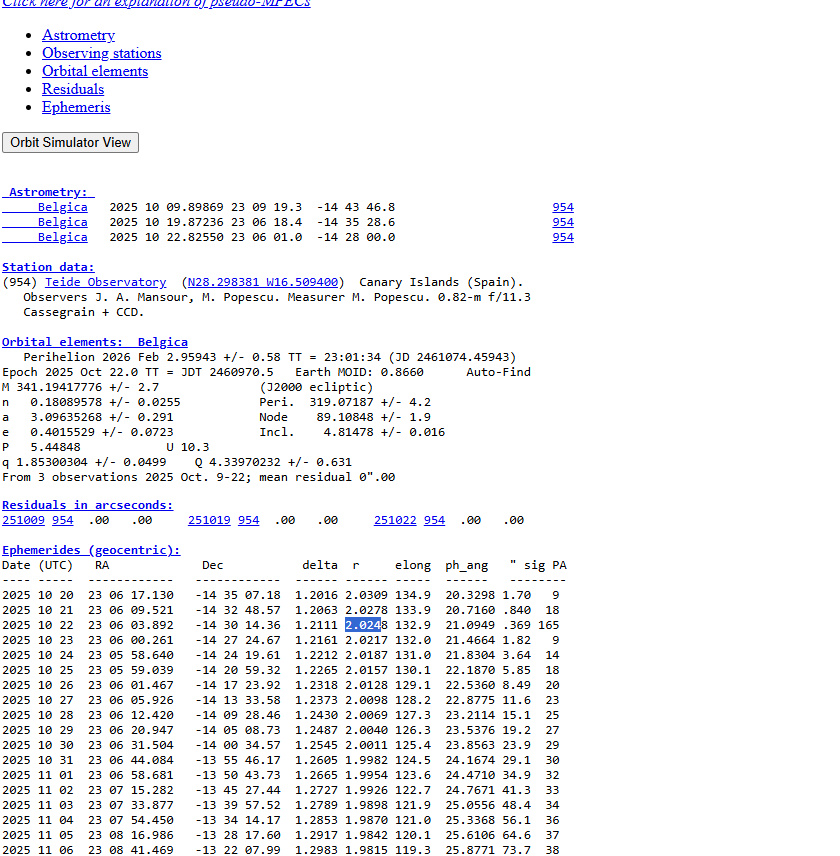

In [48]:
print("\n" + "=" * 60)
print("ASTEROID SIZE CALCULATION")
print("=" * 60)

# FOR THE MIDDLE OBSERVATION AS ABOVE
delta = 1.211  # Distance from Earth to asteroid (AU)
Rh = 2.0248     # Distance from Sun to asteroid (AU)
alpha = 21.0949  # Phase angle (degrees)
print(f"\nOrbit parameters (from fit_orb):")
print(f"  Earth-asteroid distance (Δ): {delta:.4f} AU")
print(f"  Sun-asteroid distance (Rh): {Rh:.4f} AU")
print(f"  Phase angle (α): {alpha:.2f}°")

# Convert R magnitude to mR
# You already have V magnitude, need to convert to R magnitude
# Typical V-R for asteroids is ~0.4-0.5, or use your measured V-R color

mR = asteroid_calibrated_mags['V'] + vr  # R magnitude = V magnitude + (V-R) color
mR_err = np.sqrt(asteroid_calibrated_mags_err['V']**2 + vr_err**2)

print(f"\nPhotometry:")
print(f"  V magnitude: {asteroid_calibrated_mags['V']:.3f} ± {asteroid_calibrated_mags_err['V']:.3f}")
print(f"  V-R color: {vr:.3f}")
print(f"  R magnitude (mR): {mR:.3f} ± {mR_err:.3f}")

# Use the properties from spectral classification
pR = selected_properties['pR']
pR_err = selected_properties['pR_err']
beta = selected_properties['beta']

print(f"\nSpectral type {best_type} parameters:")
print(f"  Albedo (pR): {pR:.3f} ± {pR_err:.3f}")
print(f"  Phase coefficient (β): {beta:.3f} mag/deg")

# Calculate asteroid radius using Equation 1
m_sun = -27.09  # Apparent magnitude of the Sun in R band

exponent = 0.4 * (m_sun - mR + beta * alpha)
rhs = 2.238e22 * Rh**2 * delta**2 * 10**exponent

# Solve for radius r (in meters)
r_squared = rhs / pR
r_meters = np.sqrt(r_squared)
r_km = r_meters / 1000

print(f"\n{'=' * 60}")
print(f"ASTEROID RADIUS CALCULATION")
print(f"{'=' * 60}")
print(f"\nRadius: {r_meters:.2e} meters")
print(f"Radius: {r_km:.2f} km")
print(f"Diameter: {2*r_km:.2f} km")

# Error propagation
rel_err_albedo = pR_err / pR
rel_err_mag = 0.4 * np.log(10) * mR_err
rel_err_total = 0.5 * np.sqrt(rel_err_albedo**2 + rel_err_mag**2)
r_km_err = r_km * rel_err_total

print(f"\nWith uncertainties:")
print(f"Diameter: {2*r_km:.2f} ± {2*r_km_err:.2f} km")

# =============================================================================
# MASS CALCULATION (if density is available)
# =============================================================================
if selected_properties['density'] is not None:
    print(f"\n{'=' * 60}")
    print(f"ASTEROID MASS CALCULATION")
    print(f"{'=' * 60}")
    
    density = selected_properties['density']  # g/cm³
    density_err = selected_properties['density_err']
    
    # Volume of sphere: V = (4/3) * π * r³
    volume_m3 = (4/3) * np.pi * r_meters**3
    volume_km3 = volume_m3 / 1e9
    
    # Convert density to kg/m³
    density_kg_m3 = density * 1000
    density_err_kg_m3 = density_err * 1000
    
    # Mass = density × volume
    mass_kg = density_kg_m3 * volume_m3
    mass_metric_tons = mass_kg / 1000
    
    print(f"\nVolume: {volume_km3:.2f} km³")
    print(f"Assumed density: {density:.2f} ± {density_err:.2f} g/cm³")
    print(f"Mass: {mass_kg:.2e} kg")
    print(f"Mass: {mass_metric_tons:.2e} metric tons")
    
    # Error propagation for mass
    rel_err_mass = np.sqrt((density_err/density)**2 + (3*rel_err_total)**2)
    mass_kg_err = mass_kg * rel_err_mass
    
    print(f"\nWith uncertainties:")
    print(f"Mass: ({mass_kg:.2e} ± {mass_kg_err:.2e}) kg")

# =============================================================================
# SUMMARY
# =============================================================================
print(f"\n{'*' * 60}")
print(f"SUMMARY FOR ASTEROID BELGICA")
print(f"{'*' * 60}")
print(f"\nSpectral classification: Type {best_type}")
print(f"Diameter: {2*r_km:.2f} ± {2*r_km_err:.2f} km")
if selected_properties['density'] is not None:
    print(f"Estimated mass: ({mass_kg:.2e} ± {mass_kg_err:.2e}) kg")
print(f"Geometric albedo: {pR:.3f} ± {pR_err:.3f}")



ASTEROID SIZE CALCULATION

Orbit parameters (from fit_orb):
  Earth-asteroid distance (Δ): 1.2110 AU
  Sun-asteroid distance (Rh): 2.0248 AU
  Phase angle (α): 21.09°

Photometry:
  V magnitude: 14.860 ± 0.030
  V-R color: 0.488
  R magnitude (mR): 15.348 ± 0.072

Spectral type L parameters:
  Albedo (pR): 0.130 ± 0.010
  Phase coefficient (β): 0.040 mag/deg

ASTEROID RADIUS CALCULATION

Radius: 4.88e+03 meters
Radius: 4.88 km
Diameter: 9.76 km

With uncertainties:
Diameter: 9.76 ± 0.50 km

ASTEROID MASS CALCULATION

Volume: 487.39 km³
Assumed density: 3.22 ± 0.97 g/cm³
Mass: 1.57e+15 kg
Mass: 1.57e+12 metric tons

With uncertainties:
Mass: (1.57e+15 ± 5.30e+14) kg

************************************************************
SUMMARY FOR ASTEROID BELGICA
************************************************************

Spectral classification: Type L
Diameter: 9.76 ± 0.50 km
Estimated mass: (1.57e+15 ± 5.30e+14) kg
Geometric albedo: 0.130 ± 0.010


# This is so bad